# 🏗️ carteira_auto — Exploração Completa do Sistema

**Objetivo:** Testar todas as funcionalidades implementadas, compreender as fontes de dados disponíveis, seus domínios e a orquestração entre os componentes.

---

### Arquitetura em Camadas

```
┌─────────────────────────────────────────────────────────────┐
│  CLI / Dashboard Streamlit                                  │
├─────────────────────────────────────────────────────────────┤
│  DAGEngine  →  Nodes (Load → Fetch → Analyze → Export)     │
├──────────┬──────────┬───────────────┬───────────────────────┤
│ Analyzers│ Alerts   │  DataLake     │  Config / Settings    │
│ (6 nodes)│ (rules+  │  (4 SQLite)   │  (dataclasses)        │
│          │  channels│               │                       │
├──────────┴──────────┼───────────────┤                       │
│  Fetchers (7)       │  Loaders /    │                       │
│  Yahoo BCB IBGE     │  Exporters    │                       │
│  FRED DDM CVM       │  (Excel)      │                       │
│  Tesouro Direto     │               │                       │
└─────────────────────┴───────────────┴───────────────────────┘
```

### Fontes de Dados por Domínio

| Domínio | Fetcher | API Key | Dados |
|---------|---------|---------|-------|
| 🇧🇷 Macro BR | BCBFetcher | Não | Selic, CDI, IPCA, PTAX, IGP-M, TR |
| 🇧🇷 Macro BR | IBGEFetcher | Não | IPCA detalhado, PIB trimestral, Desemprego |
| 🇺🇸 Macro Global | FREDFetcher | Sim (gratuita) | Fed Funds, Treasuries, VIX, CPI, BRL/USD |
| 🏛️ Renda Fixa | TesouroDiretoFetcher | Não | LFT, NTN-B, LTN, NTN-F — taxas e PU desde 2002 |
| 📈 Ações & FIIs | YahooFinanceFetcher | Não | OHLCV, fundamentos, dividendos, recomendações |
| 📋 Dados Oficiais | CVMFetcher | Não | DFP/ITR auditados, cadastro de companhias |
| 🔑 API Premium | DDMFetcher | Sim | Notícias, expectativas Focus, curvas de juros |

### Seções deste Notebook

1. **Ambiente & Config** — Setup, detecção de API keys, constantes
2. **Renda Fixa** — Tesouro Direto (curvas, taxas, histórico)
3. **Macro Brasil** — BCB + IBGE (Selic, CDI, IPCA, PIB)
4. **Macro Global** — FRED (Fed Funds, Treasuries, VIX)
5. **Ações & Fundamentos** — Yahoo Finance (preços, info, dividendos)
6. **Dados Oficiais** — CVM (DFP, mapeamento ticker→CNPJ)
7. **DataLake** — Ingestão, persistência e consulta (SQLite)
8. **Pipeline Engine** — DAG, resolução de dependências, execução
9. **Analyzers** — Portfolio, Risk, Macro, Market, Rebalancer
10. **Alertas** — Regras, canais, avaliação
11. **Resumo do Sistema** — Inventário e status

---
## 1. ⚙️ Ambiente & Configuração

In [1]:
import os, sys, warnings, tempfile
from pathlib import Path

warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 30)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('ggplot')
plt.rcParams['figure.dpi'] = 100

# Detecção de API keys
from carteira_auto.config import settings

FRED_OK = bool(settings.API_KEYS.get('fred'))
DDM_OK = bool(settings.API_KEYS.get('ddm'))

print('=' * 60)
print('  carteira_auto — Ambiente de Exploração')
print('=' * 60)
print(f'  Python:       {sys.version.split()[0]}')
print(f'  Pandas:       {pd.__version__}')
print(f'  Data dir:     {settings.paths.DATA_DIR}')
print(f'  Lake dir:     {settings.paths.LAKE_DIR}')
print(f'  FRED API key: {"✅ configurada" if FRED_OK else "❌ não configurada"}')
print(f'  DDM API key:  {"✅ configurada" if DDM_OK else "❌ não configurada"}')
print('=' * 60)

  carteira_auto — Ambiente de Exploração
  Python:       3.12.4
  Pandas:       2.3.3
  Data dir:     /Users/bernardogalvao/Desktop/Projetos/Finanças/carteira_auto/data
  Lake dir:     /Users/bernardogalvao/Desktop/Projetos/Finanças/carteira_auto/data/lake
  FRED API key: ✅ configurada
  DDM API key:  ✅ configurada


---
## 2. 🏛️ Renda Fixa — Tesouro Direto

**Fonte:** Tesouro Transparente (CKAN) — dados abertos, sem autenticação
**Fetcher:** `TesouroDiretoFetcher`
**Dados:** Taxas de compra/venda e PU de todos os títulos públicos desde 2002

| Tipo | Nome Antigo | Nome Novo (2025+) | Indexador |
|------|-------------|-------------------|-----------|
| LFT | LFT | Tesouro Selic | Selic (pós-fixado) |
| NTN-B | NTN-B Principal | Tesouro IPCA+ | IPCA + spread (zero cupom) |
| NTN-B c/ cupom | NTN-B | Tesouro IPCA+ com Juros Semestrais | IPCA + spread (semestral) |
| LTN | LTN | Tesouro Prefixado | Prefixado (zero cupom) |
| NTN-F | NTN-F | Tesouro Prefixado com Juros Semestrais | Prefixado (semestral) |

In [2]:
from carteira_auto.data.fetchers.tesouro_fetcher import TesouroDiretoFetcher

tesouro = TesouroDiretoFetcher()

# 2.1 — Taxas atuais (snapshot do último dia útil)
df_atual = tesouro.get_current_rates()
print(f'📅 Data de referência: {df_atual["data"].iloc[0].date()}')
print(f'📊 Títulos em oferta: {len(df_atual)}')
print()
df_atual[['tipo', 'vencimento', 'taxa_compra', 'taxa_venda', 'pu_compra']].sort_values('taxa_compra', ascending=False)

2026-03-25 18:55:31 INFO     carteira_auto.data.fetchers.tesouro_fetcher: TesouroDireto:     ]8;id=475180;file:///Users/bernardogalvao/Desktop/Projetos/Finanças/carteira_auto/src/carteira_auto/data/fetchers/tesouro_fetcher.py\tesouro_fetcher.py]8;;\:]8;id=526888;file:///Users/bernardogalvao/Desktop/Projetos/Finanças/carteira_auto/src/carteira_auto/data/fetchers/tesouro_fetcher.py#148\148]8;;\
                             taxas de 2026-03-24, 60 títulos                                                       

📅 Data de referência: 2026-03-24
📊 Títulos em oferta: 60



,tipo,vencimento,taxa_compra,taxa_venda,pu_compra
37463,Tesouro IPCA+,15/08/2026,"9,10","9,22","4480,98"
37453,Tesouro IPCA+ com Juros Semestrais,15/08/2026,"9,10","9,22","4613,46"
37489,Tesouro Educa+,15/12/2030,"8,01","8,13","3689,70"
37464,Tesouro IGPM+ com Juros Semestrais,01/01/2031,"7,97","8,09","7613,01"
37449,Tesouro IPCA+ com Juros Semestrais,15/08/2030,"7,96","8,08","4355,92"
...,...,...,...,...,...
37445,Tesouro Prefixado,01/01/2027,"13,81","13,93","905,67"
37440,Tesouro Selic,01/03/2031,"0,09","0,10","18577,21"
37438,Tesouro Selic,01/03/2029,"0,04","0,05","18639,99"
37439,Tesouro Selic,01/03/2028,"0,01","0,02","18657,20"


In [3]:
# 2.2 — Títulos disponíveis no histórico
titulos = tesouro.get_available_titles()
print(f'📋 {len(titulos)} tipos de títulos no histórico:')
for i, t in enumerate(titulos, 1):
    print(f'   {i:2d}. {t}')

2026-03-25 18:55:34 INFO     carteira_auto.data.fetchers.tesouro_fetcher: TesouroDireto:     ]8;id=342426;file:///Users/bernardogalvao/Desktop/Projetos/Finanças/carteira_auto/src/carteira_auto/data/fetchers/tesouro_fetcher.py\tesouro_fetcher.py]8;;\:]8;id=394296;file:///Users/bernardogalvao/Desktop/Projetos/Finanças/carteira_auto/src/carteira_auto/data/fetchers/tesouro_fetcher.py#189\189]8;;\
                             histórico com 169058 observações                                                      

📋 8 tipos de títulos no histórico:
    1. Tesouro Educa+
    2. Tesouro IGPM+ com Juros Semestrais
    3. Tesouro IPCA+
    4. Tesouro IPCA+ com Juros Semestrais
    5. Tesouro Prefixado
    6. Tesouro Prefixado com Juros Semestrais
    7. Tesouro Renda+ Aposentadoria Extra
    8. Tesouro Selic


                    INFO     carteira_auto.data.fetchers.tesouro_fetcher: TesouroDireto:     ]8;id=703178;file:///Users/bernardogalvao/Desktop/Projetos/Finanças/carteira_auto/src/carteira_auto/data/fetchers/tesouro_fetcher.py\tesouro_fetcher.py]8;;\:]8;id=42567;file:///Users/bernardogalvao/Desktop/Projetos/Finanças/carteira_auto/src/carteira_auto/data/fetchers/tesouro_fetcher.py#296\296]8;;\
                             curva NTN-B — 10 vértices em 2026-03-24                                               

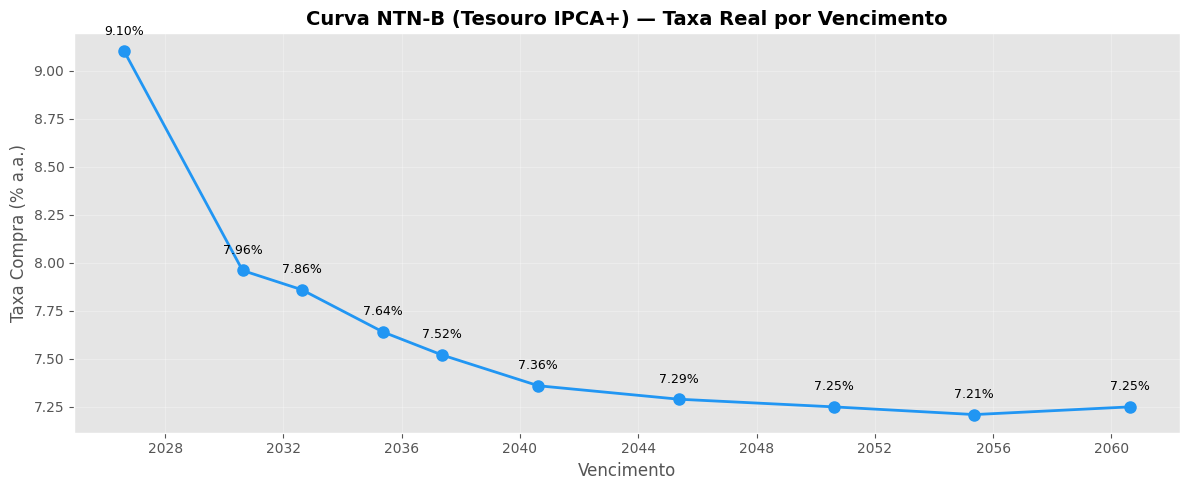

Curva com 10 vértices — data base: 2026-03-24


In [4]:
# 2.3 — Curva NTN-B (IPCA+) — spread por vencimento
curve = tesouro.get_ntnb_curve()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(curve['vencimento'], curve['taxa_compra'], 'o-', color='#2196F3', markersize=8, linewidth=2)
for _, row in curve.iterrows():
    ax.annotate(f'{row["taxa_compra"]:.2f}%',
                (row['vencimento'], row['taxa_compra']),
                textcoords='offset points', xytext=(0, 12), ha='center', fontsize=9)
ax.set_title('Curva NTN-B (Tesouro IPCA+) — Taxa Real por Vencimento', fontsize=14, fontweight='bold')
ax.set_xlabel('Vencimento')
ax.set_ylabel('Taxa Compra (% a.a.)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print(f'Curva com {len(curve)} vértices — data base: {curve["data"].iloc[0].date()}')

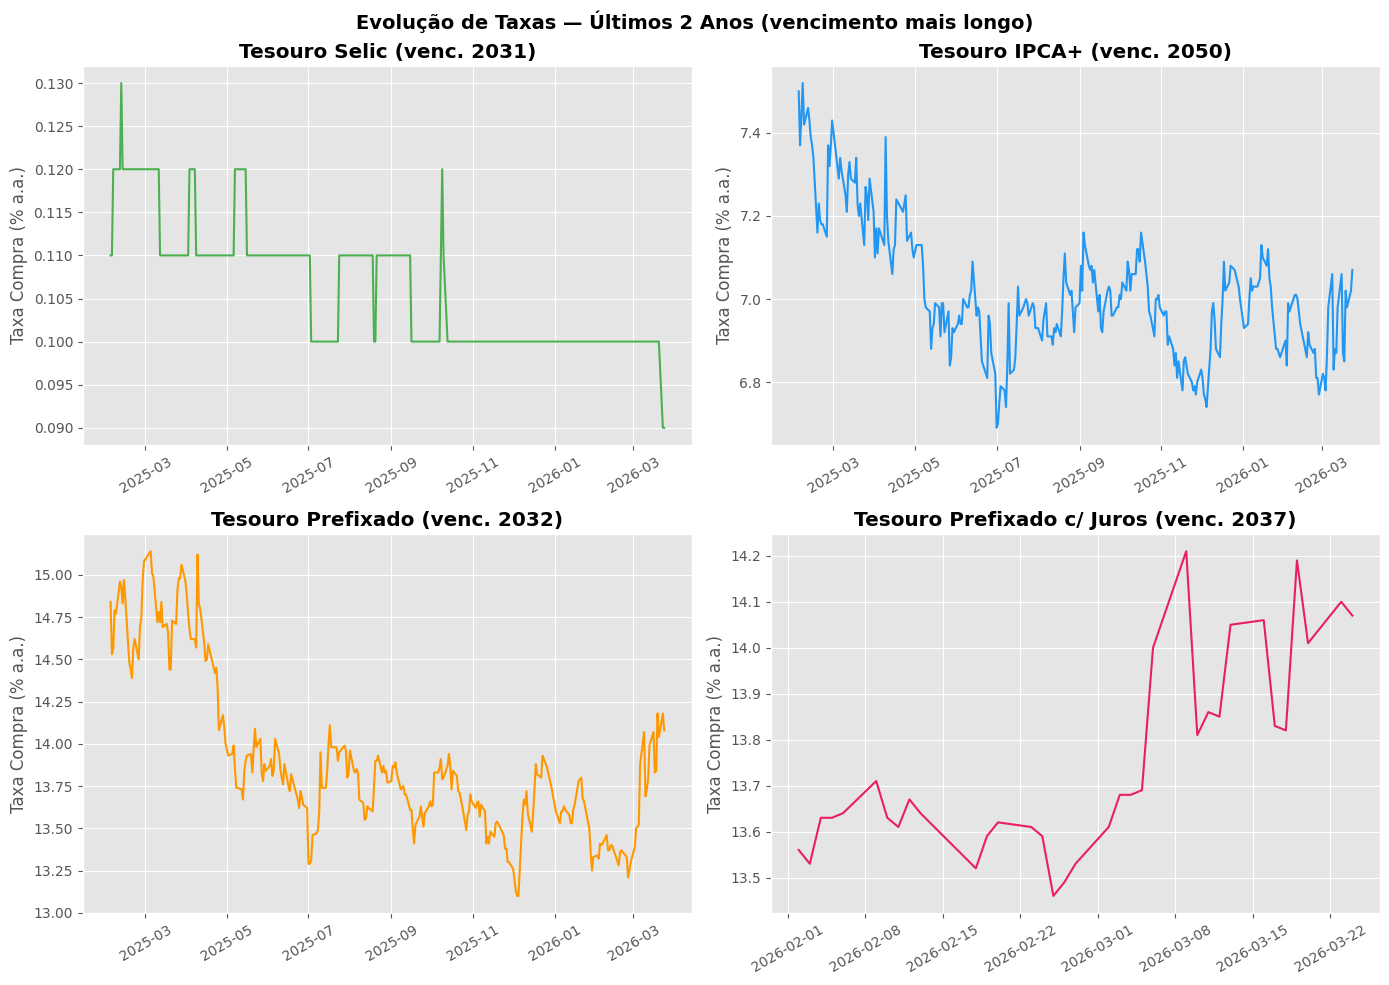

In [5]:
# 2.4 — Histórico por tipo de título (últimos 2 anos)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
tipos = [('LFT', 'Tesouro Selic', '#4CAF50'), ('NTN-B', 'Tesouro IPCA+', '#2196F3'),
         ('LTN', 'Tesouro Prefixado', '#FF9800'), ('NTN-F', 'Tesouro Prefixado c/ Juros', '#E91E63')]

for ax, (tipo, label, cor) in zip(axes.flat, tipos):
    df_tipo = tesouro.get_price_history_by_type(tipo)
    if not df_tipo.empty and 'data' in df_tipo.columns:
        # Últimos 2 anos, vencimento mais longo disponível
        recente = df_tipo[df_tipo['data'] >= pd.Timestamp.now() - pd.DateOffset(years=2)]
        if not recente.empty:
            venc_max = recente['vencimento'].max()
            serie = recente[recente['vencimento'] == venc_max].sort_values('data')
            ax.plot(serie['data'], serie['taxa_compra'], color=cor, linewidth=1.5)
            ax.set_title(f'{label} (venc. {venc_max.year})', fontweight='bold')
            ax.set_ylabel('Taxa Compra (% a.a.)')
            ax.tick_params(axis='x', rotation=30)

fig.suptitle('Evolução de Taxas — Últimos 2 Anos (vencimento mais longo)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

---
## 3. 🇧🇷 Macro Brasil — BCB + IBGE

### BCBFetcher — Banco Central do Brasil (SGS API)
**Fonte:** Sistema Gerenciador de Séries Temporais (SGS) — sem autenticação
**Séries:** Selic meta, Selic diária, CDI, IPCA, IGP-M, PTAX, TR, PIB mensal

### IBGEFetcher — Instituto Brasileiro de Geografia e Estatística (SIDRA)
**Fonte:** API SIDRA — sem autenticação
**Séries:** IPCA detalhado (grupos), PIB trimestral, taxa de desemprego (PNAD)

In [6]:
from carteira_auto.data.fetchers.bcb_fetcher import BCBFetcher

bcb = BCBFetcher()

# 3.1 — Indicadores BCB: panorama atual
# get_selic() retorna a Selic Meta (SGS 432) em % a.a. — frequência diária
selic = bcb.get_selic(period_days=365 * 5)
cdi = bcb.get_cdi()
ipca = bcb.get_ipca()
igpm = bcb.get_igpm()

print('=' * 55)
print('  BCB — Indicadores Macro Brasil')
print('=' * 55)
for nome, df in [('Selic Meta', selic), ('CDI', cdi), ('IPCA', ipca), ('IGP-M', igpm)]:
    ultimo = df.iloc[-1]
    print(f'  {nome:15s}: {ultimo["valor"]:8.4f}  (último: {ultimo["data"].date()})')
print('=' * 55)

  BCB — Indicadores Macro Brasil
  Selic Meta     :  14.7500  (último: 2026-03-25)
  CDI            :   0.0543  (último: 2026-03-24)
  IPCA           :   0.7000  (último: 2026-02-01)
  IGP-M          :  -0.7300  (último: 2026-02-01)


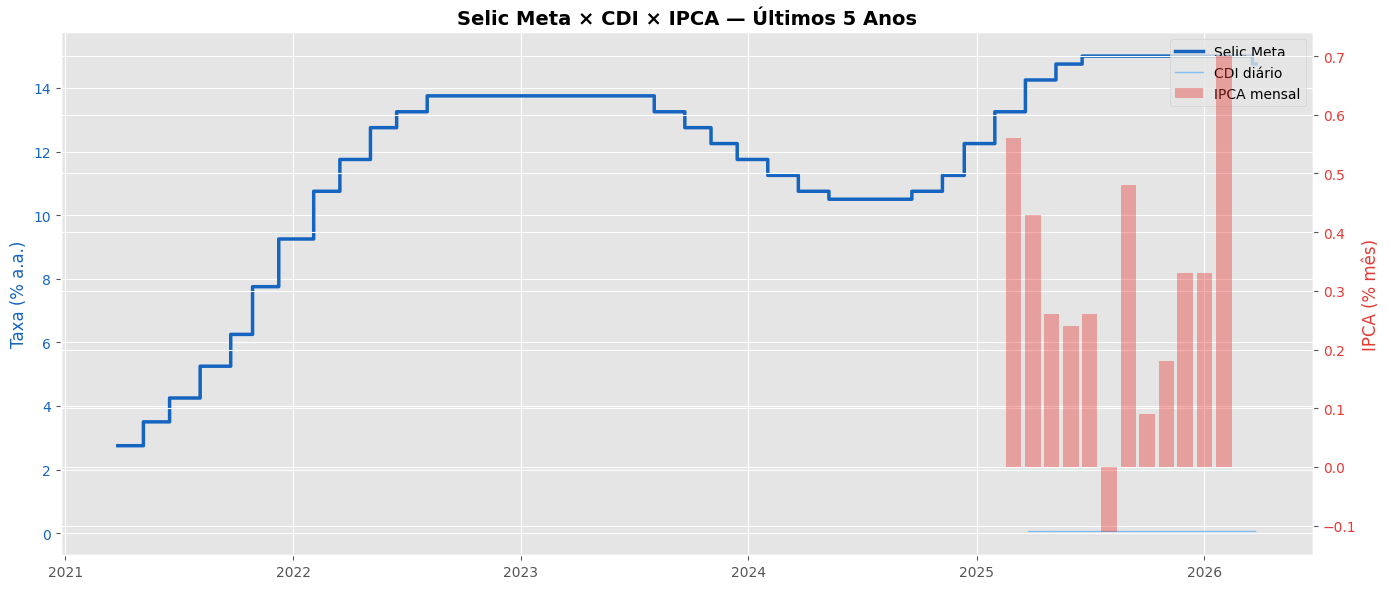

In [7]:
# 3.2 — Evolução Selic × IPCA × CDI (últimos 5 anos)
fig, ax1 = plt.subplots(figsize=(14, 6))

# Selic meta
selic_5y = selic[selic['data'] >= pd.Timestamp.now() - pd.DateOffset(years=5)]
ax1.step(selic_5y['data'], selic_5y['valor'], where='post', color='#1565C0', linewidth=2.5, label='Selic Meta')

# CDI acumulado 12m (proxy)
cdi_5y = cdi[cdi['data'] >= pd.Timestamp.now() - pd.DateOffset(years=5)]
ax1.plot(cdi_5y['data'], cdi_5y['valor'], color='#42A5F5', linewidth=1, alpha=0.6, label='CDI diário')

ax1.set_ylabel('Taxa (% a.a.)', color='#1565C0')
ax1.tick_params(axis='y', labelcolor='#1565C0')

# IPCA no eixo secundário
ax2 = ax1.twinx()
ipca_5y = ipca[ipca['data'] >= pd.Timestamp.now() - pd.DateOffset(years=5)]
ax2.bar(ipca_5y['data'], ipca_5y['valor'], width=25, alpha=0.4, color='#E53935', label='IPCA mensal')
ax2.set_ylabel('IPCA (% mês)', color='#E53935')
ax2.tick_params(axis='y', labelcolor='#E53935')

ax1.set_title('Selic Meta × CDI × IPCA — Últimos 5 Anos', fontsize=14, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
fig.tight_layout()
plt.show()

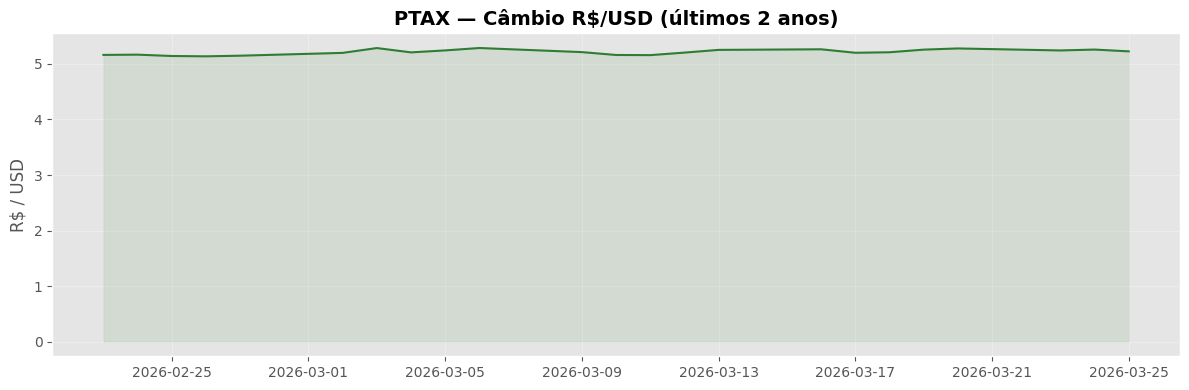

Última cotação: R$ 5.2269 em 2026-03-25


In [8]:
# 3.3 — PTAX (câmbio BRL/USD)
ptax = bcb.get_ptax()
ptax_2y = ptax[ptax['data'] >= pd.Timestamp.now() - pd.DateOffset(years=2)]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ptax_2y['data'], ptax_2y['valor'], color='#2E7D32', linewidth=1.5)
ax.fill_between(ptax_2y['data'], ptax_2y['valor'], alpha=0.1, color='#2E7D32')
ax.set_title('PTAX — Câmbio R$/USD (últimos 2 anos)', fontsize=14, fontweight='bold')
ax.set_ylabel('R$ / USD')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print(f'Última cotação: R$ {ptax.iloc[-1]["valor"]:.4f} em {ptax.iloc[-1]["data"].date()}')

In [ ]:
from carteira_auto.data.fetchers.ibge_fetcher import IBGEFetcher
from carteira_auto.data.fetchers.ddm_fetcher import DDMFetcher

ibge = IBGEFetcher()
ddm = DDMFetcher()   # Inicializa DDM aqui para uso posterior (screening, ETTJ, etc.)

# ── Configuração temporal dinâmica ──
N_MESES_IPCA = 24    # Janela para IPCA por grupo
N_TRIM_PIB   = 20    # Trimestres para PIB
N_MESES_DESEMP = 24  # Trimestres móveis para desemprego

# 3.4 — IBGE: IPCA detalhado por grupo
ipca_grupos = ibge.get_ipca_detailed(months=N_MESES_IPCA)
pib = ibge.get_pib(quarters=N_TRIM_PIB)
desemprego = ibge.get_unemployment(months=N_MESES_DESEMP)

# ── IPCA por Grupo (célula dedicada) ──
if not ipca_grupos.empty and 'grupo' in ipca_grupos.columns:
    fig, ax = plt.subplots(figsize=(14, 7))

    pivot = ipca_grupos.pivot_table(index='periodo', columns='grupo', values='valor')
    ultimo_mes = pivot.index[-1] if len(pivot) > 0 else 'N/D'

    # Top 8 grupos por variação acumulada
    acum = pivot.sum().sort_values(ascending=False)
    top_grupos = acum.head(8).index.tolist()
    pivot_top = pivot[top_grupos].tail(12)

    pivot_top.plot(kind='bar', ax=ax, width=0.8, alpha=0.85)
    ax.set_title(f'IPCA por Grupo — Variação Mensal (%) — Últimos 12 meses até {ultimo_mes}',
                 fontsize=14, fontweight='bold')
    ax.set_ylabel('Variação (%)', fontsize=12)
    ax.set_xlabel('')
    ax.legend(title='Grupo', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.axhline(y=0, color='black', linewidth=0.5, linestyle='-')
    ax.tick_params(axis='x', rotation=45)
    fig.tight_layout()
    plt.show()

    print(f'📊 IPCA Grupos: {len(ipca_grupos)} observações | {len(pivot.columns)} grupos | Último: {ultimo_mes}')
else:
    print('⚠️  Sem dados de IPCA por grupo')

In [ ]:
# 3.5 — PIB Trimestral — Variação % (IBGE SIDRA, tabela 5932)
if not pib.empty:
    fig, ax = plt.subplots(figsize=(14, 6))

    valores = pib['valor'].values
    periodos = pib['periodo'].values if 'periodo' in pib.columns else [str(i) for i in range(len(pib))]
    cores = ['#2E7D32' if v >= 0 else '#C62828' for v in valores]

    bars = ax.bar(range(len(valores)), valores, color=cores, alpha=0.85, edgecolor='white', linewidth=0.5)

    # Linha de média do período
    media = valores.mean()
    ax.axhline(y=media, color='#1565C0', linestyle='--', linewidth=1.5, alpha=0.7,
               label=f'Média do período: {media:.1f}%')
    ax.axhline(y=0, color='black', linewidth=0.8)

    # Anotação do último valor
    ultimo_val = valores[-1]
    ultimo_per = periodos[-1]
    ax.annotate(f'{ultimo_val:+.1f}%\n({ultimo_per})',
                xy=(len(valores)-1, ultimo_val),
                xytext=(10, 15 if ultimo_val >= 0 else -25),
                textcoords='offset points',
                fontsize=12, fontweight='bold',
                color='#2E7D32' if ultimo_val >= 0 else '#C62828',
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.2))

    ax.set_title(f'PIB Trimestral — Variação % em relação ao mesmo trimestre do ano anterior',
                 fontsize=14, fontweight='bold')
    ax.set_ylabel('Variação (%)', fontsize=12)
    ax.set_xticks(range(len(periodos)))
    ax.set_xticklabels(periodos, rotation=45, ha='right', fontsize=9)
    ax.legend(fontsize=11, loc='upper left')
    ax.grid(axis='y', alpha=0.3)
    fig.tight_layout()
    plt.show()

    print(f'📊 PIB: {len(pib)} trimestres | Último: {ultimo_per} = {ultimo_val:+.1f}% | Média: {media:.1f}%')
else:
    print('⚠️  Sem dados de PIB trimestral')

In [ ]:
# 3.6 — Taxa de Desemprego — PNAD Contínua (IBGE SIDRA, tabela 6381)
if not desemprego.empty:
    fig, ax = plt.subplots(figsize=(14, 6))

    valores = desemprego['valor'].values
    periodos = desemprego['periodo'].values if 'periodo' in desemprego.columns else [str(i) for i in range(len(desemprego))]

    ax.plot(range(len(valores)), valores, 'o-', color='#D32F2F', linewidth=2.5, markersize=6, alpha=0.9)
    ax.fill_between(range(len(valores)), valores, alpha=0.15, color='#D32F2F')

    # Estatísticas
    val_min, val_max, val_media = valores.min(), valores.max(), valores.mean()
    ultimo_val = valores[-1]
    ultimo_per = periodos[-1]

    # Linhas de referência
    ax.axhline(y=val_media, color='#1565C0', linestyle='--', linewidth=1.5, alpha=0.7,
               label=f'Média: {val_media:.1f}%')
    ax.axhline(y=val_min, color='#2E7D32', linestyle=':', linewidth=1, alpha=0.5,
               label=f'Mín: {val_min:.1f}%')
    ax.axhline(y=val_max, color='#C62828', linestyle=':', linewidth=1, alpha=0.5,
               label=f'Máx: {val_max:.1f}%')

    # Anotação do último valor
    ax.annotate(f'{ultimo_val:.1f}%\n({ultimo_per})',
                xy=(len(valores)-1, ultimo_val),
                xytext=(10, -25),
                textcoords='offset points',
                fontsize=12, fontweight='bold', color='#D32F2F',
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.2))

    ax.set_title(f'Taxa de Desocupação — PNAD Contínua (trimestre móvel)',
                 fontsize=14, fontweight='bold')
    ax.set_ylabel('Taxa (%)', fontsize=12)
    ax.set_xticks(range(0, len(periodos), max(1, len(periodos)//8)))
    ax.set_xticklabels([periodos[i] for i in range(0, len(periodos), max(1, len(periodos)//8))],
                       rotation=45, ha='right', fontsize=9)
    ax.legend(fontsize=10, loc='upper right')
    ax.grid(axis='y', alpha=0.3)
    fig.tight_layout()
    plt.show()

    print(f'📊 Desemprego: {len(desemprego)} trimestres móveis | Último: {ultimo_per} = {ultimo_val:.1f}%')
    print(f'   Faixa: {val_min:.1f}% — {val_max:.1f}% | Média: {val_media:.1f}%')
else:
    print('⚠️  Sem dados de desemprego (PNAD)')

---
## 4. 🇺🇸 Macro Global — FRED

**Fonte:** Federal Reserve Economic Data (FRED) — API gratuita com chave
**Fetcher:** `FREDFetcher`
**Séries:** Fed Funds Rate, Treasury yields (2Y, 10Y, 30Y), VIX, CPI, GDP, DXY, BRL/USD

> Requer API key (`FRED_API_KEY`). Células executam apenas se a chave estiver configurada.

In [10]:
if FRED_OK:
    from carteira_auto.data.fetchers.fred_fetcher import FREDFetcher
    fred = FREDFetcher()

    # 4.1 — Séries disponíveis no FRED
    series_map = FREDFetcher.list_series()
    print(f'📊 {len(series_map)} séries configuradas no FREDFetcher:')
    for key, info in series_map.items():
        print(f'   {key:20s} → {info["nome"]}')   # chave é "nome" (português)
else:
    print('⚠️  FRED API key não configurada — seção pulada')
    print('   Configure em .env: FRED_API_KEY=sua_chave_aqui')
    print('   Obtenha gratuitamente em: https://fred.stlouisfed.org/docs/api/api_key.html')

📊 19 séries configuradas no FREDFetcher:
   DFF                  → Fed Funds Rate
   CPIAUCSL             → CPI EUA
   PCEPILFE             → Core PCE
   DFII10               → TIPS 10Y Real Yield
   DGS3MO               → Treasury 3M
   DGS2                 → Treasury 2Y
   DGS10                → Treasury 10Y
   DGS30                → Treasury 30Y
   T10Y2Y               → Spread 10Y-2Y
   GDP                  → PIB EUA Nominal
   GDPC1                → PIB EUA Real
   UNRATE               → Desemprego EUA
   INDPRO               → Produção Industrial EUA
   VIXCLS               → VIX
   BAMLH0A0HYM2         → High Yield Spread
   T10YIE               → Breakeven Inflação 10Y
   DEXBZUS              → BRL/USD
   DEXUSEU              → EUR/USD
   DEXCHUS              → CNY/USD


In [ ]:
if FRED_OK:
    # 4.2 — Painel macro EUA: Fed Funds × Treasury 10Y × VIX
    fed = fred.get_fed_funds_rate()
    t10y = fred.get_treasury_10y()
    vix = fred.get_vix()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    HOJE = pd.Timestamp.now()
    N_ANOS_FRED = 3

    # FRED retorna RangeIndex — converter coluna 'date' para datetime
    fed_date = pd.to_datetime(fed['date'])
    t10y_date = pd.to_datetime(t10y['date'])
    vix_date = pd.to_datetime(vix['date'])

    # Fed Funds
    mask_fed = fed_date >= HOJE - pd.DateOffset(years=N_ANOS_FRED)
    axes[0].step(fed_date[mask_fed], fed.loc[mask_fed, 'value'], where='post', color='#1565C0', linewidth=2)
    axes[0].set_title('Fed Funds Rate', fontweight='bold')
    axes[0].set_ylabel('% a.a.')
    ultimo_fed = fed.loc[mask_fed, 'value'].iloc[-1] if mask_fed.any() else None
    if ultimo_fed is not None:
        axes[0].annotate(f'{ultimo_fed:.2f}%', xy=(1, ultimo_fed), xycoords=('axes fraction', 'data'),
                         fontsize=11, fontweight='bold', color='#1565C0', ha='right')

    # Treasury 10Y
    mask_t10 = t10y_date >= HOJE - pd.DateOffset(years=N_ANOS_FRED)
    axes[1].plot(t10y_date[mask_t10], t10y.loc[mask_t10, 'value'], color='#2E7D32', linewidth=1.5)
    axes[1].set_title('Treasury 10Y Yield', fontweight='bold')
    axes[1].set_ylabel('% a.a.')
    ultimo_t10 = t10y.loc[mask_t10, 'value'].iloc[-1] if mask_t10.any() else None
    if ultimo_t10 is not None:
        axes[1].annotate(f'{ultimo_t10:.2f}%', xy=(1, ultimo_t10), xycoords=('axes fraction', 'data'),
                         fontsize=11, fontweight='bold', color='#2E7D32', ha='right')

    # VIX (último 1 ano)
    mask_vix = vix_date >= HOJE - pd.DateOffset(years=1)
    axes[2].fill_between(vix_date[mask_vix], vix.loc[mask_vix, 'value'], alpha=0.3, color='#E65100')
    axes[2].plot(vix_date[mask_vix], vix.loc[mask_vix, 'value'], color='#E65100', linewidth=1.5)
    axes[2].set_title('VIX — Volatilidade Implícita', fontweight='bold')
    axes[2].set_ylabel('Índice')
    axes[2].axhline(y=20, color='gray', linestyle='--', alpha=0.5, label='VIX=20')
    axes[2].legend(fontsize=9)

    fig.suptitle(f'Macro EUA — Últimos {N_ANOS_FRED} anos (FRED)', fontsize=14, fontweight='bold')
    fig.tight_layout()
    plt.show()

    print(f'📊 Fed Funds: {len(fed)} obs | Treasury 10Y: {len(t10y)} obs | VIX: {len(vix)} obs')
else:
    print('⚠️  FRED não disponível — seção pulada')

---
## 5. 📈 Ações & Fundamentos — Yahoo Finance

**Fonte:** Yahoo Finance (yfinance) — sem autenticação
**Fetcher:** `YahooFinanceFetcher`
**Dados:** OHLCV diário, informações fundamentalistas, dividendos, recomendações de analistas, splits

Suporta ações brasileiras (`.SA`), ETFs, FIIs, índices globais, commodities e crypto.

/Users/bernardogalvao/Desktop/Projetos/Finanças/carteira_auto/venv/lib/python3.12/site-packages/yfinance/utils.py:167: DeprecationWarning: enable_debug_mode() is replaced by: yf.config.debug.logging = True (or False to disable)
  warnings.warn("enable_debug_mode() is replaced by: yf.config.debug.logging = True (or False to disable)", DeprecationWarning)


2026-03-25 18:08:06 INFO     carteira_auto.data.fetchers.yahoo_fetcher: Modo debug do yfinance  ]8;id=509562;file:///Users/bernardogalvao/Desktop/Projetos/Finanças/carteira_auto/src/carteira_auto/data/fetchers/yahoo_fetcher.py\yahoo_fetcher.py]8;;\:]8;id=56042;file:///Users/bernardogalvao/Desktop/Projetos/Finanças/carteira_auto/src/carteira_auto/data/fetchers/yahoo_fetcher.py#49\49]8;;\
                             ativado                                                                               

                    INFO     carteira_auto.data.fetchers.yahoo_fetcher: YahooFinanceFetcher     ]8;id=499796;file:///Users/bernardogalvao/Desktop/Projetos/Finanças/carteira_auto/src/carteira_auto/data/fetchers/yahoo_fetcher.py\yahoo_fetcher.py]8;;\:]8;id=372433;file:///Users/bernardogalvao/Desktop/Projetos/Finanças/carteira_auto/src/carteira_auto/data/fetchers/yahoo_fetcher.py#39\39]8;;\
                             inicializado: workers=12, timeout=30s, retries=3                                      

[*********************100%***********************]  5 of 5 completed


                    INFO     carteira_auto.data.fetchers.yahoo_fetcher: Dados históricos       ]8;id=930559;file:///Users/bernardogalvao/Desktop/Projetos/Finanças/carteira_auto/src/carteira_auto/data/fetchers/yahoo_fetcher.py\yahoo_fetcher.py]8;;\:]8;id=882482;file:///Users/bernardogalvao/Desktop/Projetos/Finanças/carteira_auto/src/carteira_auto/data/fetchers/yahoo_fetcher.py#117\117]8;;\
                             obtidos para ['PETR4.SA', 'VALE3.SA', 'ITUB4.SA', 'WEGE3.SA',                         
                             'ABEV3.SA']: 251 registros                                                            

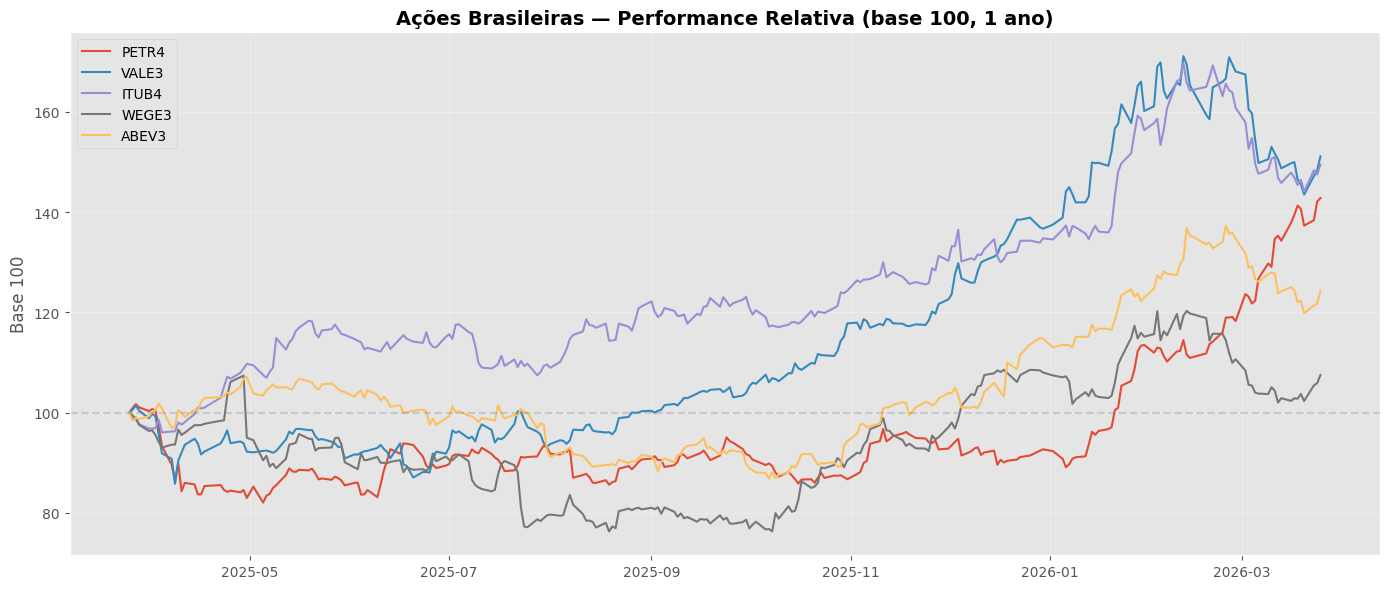

In [12]:
from carteira_auto.data.fetchers.yahoo_fetcher import YahooFinanceFetcher

yahoo = YahooFinanceFetcher()

# 5.1 — Preços históricos de ações brasileiras
tickers_br = ['PETR4.SA', 'VALE3.SA', 'ITUB4.SA', 'WEGE3.SA', 'ABEV3.SA']
df_precos = yahoo.get_historical_price_data(tickers_br, period='1y')

fig, ax = plt.subplots(figsize=(14, 6))
for ticker in tickers_br:
    col = [c for c in df_precos.columns if ticker.replace('.SA', '') in str(c) and 'Close' in str(c)]
    if col:
        serie = df_precos[col[0]].dropna()
        # Normaliza para base 100
        serie_norm = (serie / serie.iloc[0]) * 100
        ax.plot(serie_norm.index, serie_norm, linewidth=1.5, label=ticker.replace('.SA', ''))

ax.axhline(y=100, color='gray', linestyle='--', alpha=0.3)
ax.set_title('Ações Brasileiras — Performance Relativa (base 100, 1 ano)', fontsize=14, fontweight='bold')
ax.set_ylabel('Base 100')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

In [13]:
# 5.2 — Informações fundamentalistas
info = yahoo.get_basic_info('PETR4.SA')
if info:
    campos = ['shortName', 'sector', 'industry', 'marketCap', 'trailingPE',
              'forwardPE', 'dividendYield', 'beta', 'fiftyTwoWeekHigh', 'fiftyTwoWeekLow']
    print('📋 PETR4 — Dados Fundamentalistas')
    print('-' * 45)
    for c in campos:
        val = info.get(c, 'N/D')
        if isinstance(val, float):
            if 'Yield' in c:
                val = f'{val*100:.2f}%'
            elif 'Cap' in c:
                val = f'R$ {val/1e9:.1f}B'
            else:
                val = f'{val:.2f}'
        print(f'  {c:22s}: {val}')

📋 PETR4 — Dados Fundamentalistas
---------------------------------------------
  shortName             : PETROBRAS   PN      N2
  sector                : Energy
  industry              : Oil & Gas Integrated
  marketCap             : 612214833152
  trailingPE            : 5.82
  forwardPE             : 4.23
  dividendYield         : 827.00%
  beta                  : 0.16
  fiftyTwoWeekHigh      : 48.13
  fiftyTwoWeekLow       : 28.86


In [ ]:
# 5.3 — Dividendos e recomendações
divs = yahoo.get_dividends('PETR4.SA')
recs = yahoo.get_recommendations('PETR4.SA')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histórico de dividendos
if divs and 'dividends' in divs:
    df_div = divs['dividends']
    if isinstance(df_div, pd.DataFrame) and not df_div.empty:
        recent_div = df_div.tail(20)
        axes[0].bar(range(len(recent_div)), recent_div.iloc[:, 0], color='#4CAF50', alpha=0.8)
        axes[0].set_title('PETR4 — Últimos 20 Dividendos', fontweight='bold')
        axes[0].set_ylabel('R$ / ação')
    elif isinstance(df_div, pd.Series) and not df_div.empty:
        recent_div = df_div.tail(20)
        axes[0].bar(range(len(recent_div)), recent_div.values, color='#4CAF50', alpha=0.8)
        axes[0].set_title('PETR4 — Últimos 20 Dividendos', fontweight='bold')
        axes[0].set_ylabel('R$ / ação')

# Recomendações de analistas
if recs and isinstance(recs, dict):
    rec_data = recs.get('recommendations', recs)
    if isinstance(rec_data, pd.DataFrame) and not rec_data.empty:
        axes[1].set_title('PETR4 — Recomendações', fontweight='bold')
        rec_data.tail(5).plot(kind='barh', ax=axes[1])
    else:
        axes[1].text(0.5, 0.5, 'Dados indisponíveis', ha='center', va='center', transform=axes[1].transAxes)
        axes[1].set_title('PETR4 — Recomendações', fontweight='bold')

fig.tight_layout()
plt.show()

# Batch info — múltiplos ativos
batch = yahoo.get_batch_info(['PETR4.SA', 'VALE3.SA', 'WEGE3.SA'], fields=['shortName', 'trailingPE', 'dividendYield'])
print('\n📊 Comparação rápida:')
for ticker, data in batch.items():
    pe = data.get('trailingPE', 'N/D')
    dy = data.get('dividendYield', 0) or 0
    print(f'  {ticker:10s}: P/L = {pe if isinstance(pe, str) else f"{pe:.1f}":>6s}  |  DY = {dy*100:.1f}%')

In [ ]:
# 5.4 — Commodities, índices globais e crypto (via Yahoo)
global_tickers = {
    'Petróleo (WTI)': 'CL=F',
    'Ouro': 'GC=F',
    'S&P 500': '^GSPC',
    'IBOVESPA': '^BVSP',
    'Bitcoin': 'BTC-USD',
}

precos_global = {}
for nome, ticker in global_tickers.items():
    p = yahoo.get_current_price(ticker)
    precos_global[nome] = p

print('🌍 Preços Globais (Yahoo Finance)')
print('-' * 40)
for nome, preco in precos_global.items():
    if preco:
        print(f'  {nome:18s}: {preco:>12,.2f}')
    else:
        print(f'  {nome:18s}: indisponível')

---
## 5.5 Analise Comparativa de Multiplos Fundamentalistas

Comparacao de metricas fundamentalistas para um universo de acoes brasileiras. Util para screening quantitativo e identificacao de oportunidades relativas.

In [ ]:
# 5.5 — Screening fundamentalista: universo de ações BR (via DDM + Yahoo)
import time

# Garante que ddm está disponível (inicializado na seção IBGE)
if 'ddm' not in dir():
    from carteira_auto.data.fetchers.ddm_fetcher import DDMFetcher
    ddm = DDMFetcher()

universo = ['PETR4', 'VALE3', 'ITUB4', 'WEGE3', 'ABEV3',
            'BBDC4', 'RENT3', 'SUZB3', 'ELET3', 'BBAS3']

# ── DDM como fonte primária de fundamentos ──
print('📊 Screening Fundamentalista via DDM API')
print('=' * 70)

fund_data = []
for ticker in universo:
    try:
        dados = ddm.get_stock_data(ticker)
        time.sleep(0.5)  # Rate limit

        if dados and isinstance(dados, list) and len(dados) > 0:
            # Pega o registro mais recente
            ultimo = dados[-1] if isinstance(dados, list) else dados
            row = {'Ticker': ticker}
            row['P/L'] = ultimo.get('price_earnings')
            row['P/VP'] = ultimo.get('price_to_book')
            row['P/EBIT'] = ultimo.get('price_to_ebit')
            row['P/Receita'] = ultimo.get('price_to_sales')
            row['LPA'] = ultimo.get('earnings_per_share')
            row['VPA'] = ultimo.get('equity_per_share')
            row['Tipo'] = ultimo.get('statement_type', 'N/D')
            row['Ref'] = ultimo.get('reference_date', 'N/D')
            fund_data.append(row)
            print(f'  ✅ {ticker}: P/L={row["P/L"]}, P/VP={row["P/VP"]}, P/EBIT={row["P/EBIT"]}')
        else:
            print(f'  ⚠️  {ticker}: sem dados retornados')
    except Exception as e:
        print(f'  ❌ {ticker}: {e}')

if fund_data:
    df_fund = pd.DataFrame(fund_data)
    print(f'\n📋 Resultado: {len(df_fund)} de {len(universo)} ações com dados')
    display(df_fund.style.format({
        'P/L': '{:.1f}', 'P/VP': '{:.2f}', 'P/EBIT': '{:.1f}',
        'P/Receita': '{:.2f}', 'LPA': '{:.2f}', 'VPA': '{:.2f}'
    }, na_rep='—').set_caption('Screening Fundamentalista — Fonte: DDM API'))
else:
    print('⚠️  Nenhum dado fundamentalista obtido via DDM')

In [ ]:
# 5.6 — Visualização: P/L vs DY vs Market Cap (bubble chart)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_plot = df_fund.dropna(subset=['P/L', 'DY (%)', 'Market Cap (R$B)'])

if not df_plot.empty:
    # Bubble chart: P/L vs DY, tamanho = Market Cap
    scatter = axes[0].scatter(
        df_plot['P/L'], df_plot['DY (%)'],
        s=df_plot['Market Cap (R$B)'] * 3,
        c=df_plot['Beta'] if 'Beta' in df_plot.columns else 'steelblue',
        cmap='RdYlGn_r', alpha=0.7, edgecolors='black', linewidth=0.5
    )
    for _, row in df_plot.iterrows():
        axes[0].annotate(row['Ticker'], (row['P/L'], row['DY (%)']),
                        fontsize=8, ha='center', va='bottom')
    axes[0].set_xlabel('P/L (Trailing)')
    axes[0].set_ylabel('Dividend Yield (%)')
    axes[0].set_title('P/L vs Dividend Yield\n(tamanho = Market Cap, cor = Beta)', fontweight='bold')
    plt.colorbar(scatter, ax=axes[0], label='Beta')
    # Linha de earnings yield = selic
    if not selic.empty:
        selic_atual = selic.iloc[-1]['valor']
        axes[0].axvline(x=100/selic_atual, color='red', linestyle='--', alpha=0.5,
                        label=f'Earnings Yield = Selic ({selic_atual:.1f}%)')
        axes[0].legend(fontsize=8)

# Radar: ROE vs P/VP (value vs quality)
df_vq = df_fund.dropna(subset=['ROE (%)', 'P/VP'])
if not df_vq.empty:
    colors = ['#2196F3' if roe > 15 else '#FF9800' if roe > 8 else '#F44336'
              for roe in df_vq['ROE (%)']]
    axes[1].barh(df_vq['Ticker'], df_vq['ROE (%)'], color=colors, alpha=0.8)
    axes[1].set_xlabel('ROE (%)')
    axes[1].set_title('ROE por Ativo\n(azul > 15%, laranja 8-15%, vermelho < 8%)', fontweight='bold')
    axes[1].axvline(x=15, color='gray', linestyle='--', alpha=0.3)

fig.suptitle('Analise Fundamentalista Comparativa', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

---
## 5.7 Analise de Risco e Correlacao

Metricas essenciais para construcao de portfolios: correlacao entre ativos, volatilidade, VaR, e retornos ajustados ao risco. Estas metricas alimentarao o Optimizer na Fase 3.

In [ ]:
# 5.7 — Retornos, volatilidade e métricas de risco

# Extrair preços de fechamento do DataFrame multi-ticker
closes = pd.DataFrame()
for ticker in tickers_br:
    col = [c for c in df_precos.columns if ticker.replace('.SA', '') in str(c) and 'Close' in str(c)]
    if col:
        closes[ticker.replace('.SA', '')] = df_precos[col[0]]

closes = closes.dropna()
returns = closes.pct_change().dropna()

# Métricas de risco por ativo
print('📊 Métricas de Risco — Últimos 12 Meses')
print('=' * 75)
print(f'{"Ativo":>8s} {"Retorno":>10s} {"Vol. Anual":>12s} {"Sharpe":>8s} {"VaR 95%":>10s} {"Max DD":>10s}')
print('-' * 75)

# Selic como taxa livre de risco
rf_diaria = (1 + selic.iloc[-1]['valor'] / 100) ** (1/252) - 1 if not selic.empty else 0

risk_data = []
for col in returns.columns:
    ret_total = (closes[col].iloc[-1] / closes[col].iloc[0] - 1) * 100
    vol_anual = returns[col].std() * np.sqrt(252) * 100
    sharpe = (returns[col].mean() - rf_diaria) / returns[col].std() * np.sqrt(252) if returns[col].std() > 0 else 0

    # VaR paramétrico 95%
    var_95 = (returns[col].mean() - 1.645 * returns[col].std()) * 100

    # Max Drawdown
    cum = (1 + returns[col]).cumprod()
    running_max = cum.cummax()
    drawdown = (cum / running_max - 1)
    max_dd = drawdown.min() * 100

    print(f'{col:>8s} {ret_total:>9.1f}% {vol_anual:>10.1f}% {sharpe:>8.2f} {var_95:>9.2f}% {max_dd:>9.1f}%')
    risk_data.append({'Ativo': col, 'Retorno (%)': ret_total, 'Vol (%)': vol_anual,
                      'Sharpe': sharpe, 'VaR 95%': var_95, 'Max DD (%)': max_dd})

print('-' * 75)
if not selic.empty:
    print(f'  Taxa livre de risco (Selic Meta): {selic.iloc[-1]["valor"]:.2f}% a.a.')
df_risk = pd.DataFrame(risk_data)

In [ ]:
# 5.8 — Matriz de correlação e fronteira risco-retorno

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1) Matriz de correlação (heatmap)
corr = returns.corr()
im = axes[0].imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_xticks(range(len(corr.columns)))
axes[0].set_yticks(range(len(corr.columns)))
axes[0].set_xticklabels(corr.columns, fontsize=8, rotation=45)
axes[0].set_yticklabels(corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        axes[0].text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7,
                    color='white' if abs(corr.iloc[i, j]) > 0.6 else 'black')
axes[0].set_title('Matriz de Correlacao\n(retornos diarios, 1 ano)', fontweight='bold')
plt.colorbar(im, ax=axes[0], shrink=0.8)

# 2) Risco vs Retorno (scatter)
if not df_risk.empty:
    axes[1].scatter(df_risk['Vol (%)'], df_risk['Retorno (%)'],
                   s=100, c=df_risk['Sharpe'], cmap='RdYlGn', edgecolors='black',
                   linewidth=0.5, zorder=5)
    for _, row in df_risk.iterrows():
        axes[1].annotate(row['Ativo'], (row['Vol (%)'], row['Retorno (%)']),
                        fontsize=9, ha='left', va='bottom')
    sc = axes[1].scatter(df_risk['Vol (%)'], df_risk['Retorno (%)'],
                        s=100, c=df_risk['Sharpe'], cmap='RdYlGn', edgecolors='black')
    plt.colorbar(sc, ax=axes[1], label='Sharpe Ratio')
    axes[1].set_xlabel('Volatilidade Anualizada (%)')
    axes[1].set_ylabel('Retorno Total (%)')
    axes[1].set_title('Risco x Retorno\n(cor = Sharpe Ratio)', fontweight='bold')
    axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.3)

# 3) Drawdown do ativo mais arriscado vs mais defensivo
if len(returns.columns) >= 2:
    # Mais volátil e menos volátil
    vols = returns.std()
    mais_vol = vols.idxmax()
    menos_vol = vols.idxmin()

    for ticker, color, label in [(mais_vol, '#F44336', f'{mais_vol} (maior vol)'),
                                   (menos_vol, '#4CAF50', f'{menos_vol} (menor vol)')]:
        cum = (1 + returns[ticker]).cumprod()
        dd = (cum / cum.cummax() - 1) * 100
        axes[2].fill_between(dd.index, dd.values, alpha=0.3, color=color)
        axes[2].plot(dd.index, dd.values, color=color, linewidth=1, label=label)
    axes[2].set_ylabel('Drawdown (%)')
    axes[2].set_title('Drawdown Comparativo', fontweight='bold')
    axes[2].legend(fontsize=8)

fig.suptitle('Analise de Risco e Diversificacao', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

# Índice de concentração (HHI)
n_ativos = len(returns.columns)
hhi = 1 / n_ativos  # Equal-weight HHI
print(f'\n📏 Diversificacao:')
print(f'  Ativos na amostra: {n_ativos}')
print(f'  HHI (equal-weight): {hhi:.4f}  (1/{n_ativos})')
print(f'  Correlacao media: {corr.values[np.triu_indices(n_ativos, k=1)].mean():.3f}')
print(f'  Correlacao maxima: {corr.values[np.triu_indices(n_ativos, k=1)].max():.3f} '
      f'({corr.columns[np.unravel_index(np.argmax(np.triu(corr.values, k=1)), corr.shape)[0]]} — '
      f'{corr.columns[np.unravel_index(np.argmax(np.triu(corr.values, k=1)), corr.shape)[1]]})')

---
## 5.9 Analise Macro Integrada: Brasil vs EUA

Cruzamento de indicadores macro para entender o contexto de investimento. Esta analise sera a base do `MacroAnalyzer` e das futuras estrategias condicionais (Fase 3).

In [ ]:
# 5.9 — Panorama Macro Consolidado: BR vs EUA

print('=' * 70)
print('  PANORAMA MACROECONOMICO CONSOLIDADO')
print('=' * 70)

# Brasil
print('\n🇧🇷 BRASIL')
print('-' * 50)

macro_br = {}
if not selic.empty:
    macro_br['Selic Meta'] = f'{selic.iloc[-1]["valor"]:.2f}% a.a.'
if not ipca.empty:
    # IPCA acumulado 12 meses
    ipca_12m = ipca.tail(12)['valor'].sum() if len(ipca) >= 12 else ipca['valor'].sum()
    macro_br['IPCA 12m'] = f'{ipca_12m:.2f}%'
    macro_br['Juro Real'] = f'{selic.iloc[-1]["valor"] - ipca_12m:.2f}%' if not selic.empty else 'N/D'
if not cdi.empty:
    macro_br['CDI'] = f'{cdi.iloc[-1]["valor"]:.4f}% a.d.'

ptax = bcb.get_ptax(period_days=5)
if not ptax.empty:
    macro_br['PTAX (BRL/USD)'] = f'R$ {ptax.iloc[-1]["valor"]:.4f}'

if not pib.empty:
    macro_br['PIB Var.'] = f'{pib.iloc[-1]["valor"]:.1f}% t/t'
if not desemprego.empty:
    macro_br['Desemprego'] = f'{desemprego.iloc[-1]["valor"]:.1f}%'

for k, v in macro_br.items():
    print(f'  {k:20s}: {v}')

# EUA (se FRED disponível)
if FRED_OK:
    print('\n🇺🇸 EUA')
    print('-' * 50)

    macro_us = {}
    try:
        ff = fred.get_fed_funds_rate()
        if not ff.empty:
            macro_us['Fed Funds Rate'] = f'{ff.iloc[-1]["value"]:.2f}%'
    except Exception:
        pass
    try:
        t10y = fred.get_treasury_10y()
        if not t10y.empty:
            macro_us['Treasury 10Y'] = f'{t10y.iloc[-1]["value"]:.2f}%'
    except Exception:
        pass
    try:
        vix = fred.get_vix()
        if not vix.empty:
            macro_us['VIX'] = f'{vix.iloc[-1]["value"]:.1f}'
    except Exception:
        pass
    try:
        spread = fred.get_yield_curve_spread()
        if not spread.empty:
            val = spread.iloc[-1]["value"]
            macro_us['Spread 10Y-2Y'] = f'{val:.2f}% ({"normal" if val > 0 else "INVERTIDA"})'
    except Exception:
        pass
    try:
        brl_usd = fred.get_brl_usd()
        if not brl_usd.empty:
            macro_us['BRL/USD (FRED)'] = f'R$ {brl_usd.iloc[-1]["value"]:.4f}'
    except Exception:
        pass

    for k, v in macro_us.items():
        print(f'  {k:20s}: {v}')

    # Diferencial de juros
    if 'Fed Funds Rate' in macro_us and not selic.empty:
        ff_val = float(macro_us['Fed Funds Rate'].replace('%', ''))
        diff = selic.iloc[-1]['valor'] - ff_val
        print(f'\n  {"Diferencial BR-US":20s}: {diff:.2f} p.p. (carry trade {"atrativo" if diff > 5 else "moderado" if diff > 2 else "baixo"})')

print('\n' + '=' * 70)

In [ ]:
# 5.10 — Retorno real vs benchmarks + análise de momentum

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1) Retorno acumulado normalizado vs IBOV
ibov = yahoo.get_historical_price_data(['^BVSP'], period='1y')
ibov_col = [c for c in ibov.columns if 'Close' in str(c)]

if ibov_col:
    ibov_close = ibov[ibov_col[0]].dropna()
    ibov_norm = (ibov_close / ibov_close.iloc[0]) * 100

    for ticker in returns.columns:
        serie = closes[ticker].dropna()
        norm = (serie / serie.iloc[0]) * 100
        axes[0, 0].plot(norm.index, norm, linewidth=1.2, label=ticker, alpha=0.8)

    axes[0, 0].plot(ibov_norm.index, ibov_norm, 'k--', linewidth=2, label='IBOV', alpha=0.7)
    axes[0, 0].axhline(y=100, color='gray', linestyle=':', alpha=0.3)
    axes[0, 0].legend(fontsize=8, ncol=3)
    axes[0, 0].set_title('Performance Relativa vs IBOV (base 100)', fontweight='bold')
    axes[0, 0].set_ylabel('Base 100')

# 2) Retorno real (descontando IPCA)
if not ipca.empty:
    ipca_12m_val = ipca.tail(12)['valor'].sum() if len(ipca) >= 12 else ipca['valor'].sum()
    retornos_nominais = [(closes[c].iloc[-1] / closes[c].iloc[0] - 1) * 100 for c in closes.columns]
    retornos_reais = [r - ipca_12m_val for r in retornos_nominais]

    x = np.arange(len(closes.columns))
    width = 0.35
    axes[0, 1].bar(x - width/2, retornos_nominais, width, label='Nominal', color='#2196F3', alpha=0.8)
    axes[0, 1].bar(x + width/2, retornos_reais, width, label='Real (- IPCA)', color='#FF9800', alpha=0.8)
    axes[0, 1].set_xticks(x)
    axes[0, 1].set_xticklabels(closes.columns, fontsize=9)
    axes[0, 1].axhline(y=0, color='black', linewidth=0.5)
    axes[0, 1].set_ylabel('Retorno (%)')
    axes[0, 1].set_title(f'Retorno Nominal vs Real\n(IPCA 12m = {ipca_12m_val:.1f}%)', fontweight='bold')
    axes[0, 1].legend()

# 3) Médias móveis (50 e 200 dias) — ativo com maior volume
ticker_mm = closes.columns[0]  # Primeiro ativo como exemplo
serie_mm = closes[ticker_mm]
mm50 = serie_mm.rolling(50).mean()
mm200 = serie_mm.rolling(200).mean()

axes[1, 0].plot(serie_mm.index, serie_mm, 'k-', linewidth=0.8, label='Preco')
axes[1, 0].plot(mm50.index, mm50, 'b-', linewidth=1.2, label='MM50', alpha=0.8)
axes[1, 0].plot(mm200.index, mm200, 'r-', linewidth=1.2, label='MM200', alpha=0.8)
axes[1, 0].fill_between(mm50.index, mm50, mm200, where=mm50 > mm200,
                        alpha=0.1, color='green', label='MM50 > MM200')
axes[1, 0].fill_between(mm50.index, mm50, mm200, where=mm50 <= mm200,
                        alpha=0.1, color='red')
axes[1, 0].set_title(f'{ticker_mm} — Medias Moveis (50/200 dias)', fontweight='bold')
axes[1, 0].set_ylabel('Preco (R$)')
axes[1, 0].legend(fontsize=8)

# 4) Distribuição de retornos diários (histograma)
for ticker in returns.columns[:3]:  # Top 3 por volume
    axes[1, 1].hist(returns[ticker] * 100, bins=50, alpha=0.4, label=ticker, density=True)
axes[1, 1].axvline(x=0, color='black', linewidth=0.5)
axes[1, 1].set_xlabel('Retorno Diario (%)')
axes[1, 1].set_ylabel('Densidade')
axes[1, 1].set_title('Distribuicao de Retornos Diarios', fontweight='bold')
axes[1, 1].legend(fontsize=8)

fig.suptitle('Analise de Performance e Momentum', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

---
## 5.11 Valuation Relativo: Renda Fixa vs Renda Variavel

Analise do premio de risco de acoes (Equity Risk Premium) comparando earnings yield das acoes com taxas de renda fixa. Quando o ERP esta comprimido, renda fixa e mais atrativa; quando esta amplo, acoes oferecem melhor valor.

In [ ]:
# 5.11 — Equity Risk Premium e atratividade relativa RF vs RV

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1) Earnings Yield (1/P/L) vs Selic vs NTN-B
if not df_fund.empty and not selic.empty:
    df_ey = df_fund.dropna(subset=['P/L']).copy()
    df_ey['EY (%)'] = 100 / df_ey['P/L']  # Earnings yield = 1/PE

    selic_val = selic.iloc[-1]['valor']

    # NTN-B IPCA+ (do Tesouro Direto, se disponível)
    try:
        taxas = TesouroDiretoFetcher().get_current_rates()
        ntnb_taxas = [t for t in taxas if 'IPCA' in t.get('titulo', '')]
        ntnb_longa = max(ntnb_taxas, key=lambda x: x.get('vencimento', '')) if ntnb_taxas else None
        ntnb_val = float(ntnb_longa['taxa_compra']) if ntnb_longa else None
    except Exception:
        ntnb_val = None

    x = np.arange(len(df_ey))
    axes[0].bar(x, df_ey['EY (%)'], color='#2196F3', alpha=0.8, label='Earnings Yield (1/PE)')
    axes[0].axhline(y=selic_val, color='#F44336', linestyle='--', linewidth=2,
                    label=f'Selic ({selic_val:.1f}%)')
    if ntnb_val:
        axes[0].axhline(y=ntnb_val, color='#4CAF50', linestyle='--', linewidth=2,
                        label=f'NTN-B longa ({ntnb_val:.1f}%)')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(df_ey['Ticker'], fontsize=9, rotation=45)
    axes[0].set_ylabel('Taxa (%)')
    axes[0].set_title('Earnings Yield vs Renda Fixa\n(acima da linha = acao atrativa)', fontweight='bold')
    axes[0].legend(fontsize=8)

    # ERP (Equity Risk Premium)
    erp = df_ey['EY (%)'].median() - selic_val
    axes[0].text(0.98, 0.02, f'ERP mediano: {erp:.1f} p.p.',
                transform=axes[0].transAxes, ha='right', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# 2) Resumo de alocação sugerida por cenário
cenarios = {
    'Juros altos\n+ inflacao alta': {'RF Pos': 60, 'RF Pre': 10, 'Acoes': 20, 'FIIs': 10},
    'Juros altos\n+ inflacao baixa': {'RF Pos': 40, 'RF Pre': 25, 'Acoes': 25, 'FIIs': 10},
    'Juros baixos\n+ inflacao baixa': {'RF Pos': 15, 'RF Pre': 15, 'Acoes': 45, 'FIIs': 25},
    'Juros baixos\n+ inflacao alta': {'RF Pos': 25, 'RF Pre': 5, 'Acoes': 40, 'FIIs': 30},
}

labels = list(cenarios.keys())
categories = list(cenarios[labels[0]].keys())
colors_alloc = ['#1565C0', '#42A5F5', '#4CAF50', '#FF9800']

bottom = np.zeros(len(labels))
for i, cat in enumerate(categories):
    vals = [cenarios[l][cat] for l in labels]
    axes[1].bar(range(len(labels)), vals, bottom=bottom, label=cat,
               color=colors_alloc[i], alpha=0.85)
    bottom += np.array(vals)

axes[1].set_xticks(range(len(labels)))
axes[1].set_xticklabels(labels, fontsize=8)
axes[1].set_ylabel('Alocacao (%)')
axes[1].set_title('Alocacao Sugerida por Cenario Macro\n(referencia para estrategias Fase 3)', fontweight='bold')
axes[1].legend(fontsize=8, loc='upper right')

# Marca o cenário atual
if not selic.empty and not ipca.empty:
    selic_val = selic.iloc[-1]['valor']
    ipca_12m = ipca.tail(12)['valor'].sum() if len(ipca) >= 12 else 5.0
    if selic_val > 10 and ipca_12m > 5:
        cenario_idx = 0
    elif selic_val > 10:
        cenario_idx = 1
    elif ipca_12m > 5:
        cenario_idx = 3
    else:
        cenario_idx = 2

    axes[1].annotate('ATUAL', xy=(cenario_idx, 105), fontsize=10, fontweight='bold',
                    ha='center', color='red')

fig.suptitle('Valuation Relativo: Renda Fixa vs Renda Variavel', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

print(f'\n📌 Cenario atual: Selic = {selic_val:.1f}%, IPCA 12m = {ipca_12m:.1f}%, Juro Real = {selic_val - ipca_12m:.1f}%')
print(f'   ERP mediano = {erp:.1f} p.p. → {"Acoes com premio razoavel" if erp > 0 else "RF mais atrativa que RV"}')

---
## 6. 📋 Dados Oficiais — CVM

**Fonte:** Comissão de Valores Mobiliários — dados abertos (sem autenticação)
**Fetcher:** `CVMFetcher`
**Dados:** Cadastro de companhias abertas, DFP/ITR (demonstrações financeiras auditadas), mapeamento ticker→CNPJ

O mapeamento ticker→CNPJ usa heurística de prefixo sobre `denom_comerc` (nome comercial) do cadastro CVM. Funciona bem para empresas cujo ticker reflete o nome (PETR4→PETROBRAS, VALE3→VALE), mas pode falhar para abreviações não-óbvias (ITUB4→Itaú Unibanco).

In [ ]:
from carteira_auto.data.fetchers.cvm_fetcher import CVMFetcher

cvm = CVMFetcher()

# 6.1 — Cadastro de companhias abertas
registry = cvm.get_company_registry()
print(f'📋 Cadastro CVM: {len(registry)} companhias')
print(f'   Colunas: {list(registry.columns)}')
print()

# Amostra de companhias ativas
if 'situacao' in registry.columns:
    ativas = registry[registry['situacao'].str.upper().str.startswith('A', na=False)]
    print(f'   Ativas: {len(ativas)}')
    cols_show = [c for c in ['razao_social', 'nome_pregao', 'cnpj', 'setor'] if c in ativas.columns]
    display(ativas[cols_show].head(10))

In [ ]:
# 6.2 — Mapeamento ticker → CNPJ
tickers_teste = ['PETR4', 'VALE3', 'WEGE3', 'EMBR3', 'ITUB4', 'ABEV3', 'BBDC4', 'BBAS3']

print('🔗 Mapeamento Ticker → CNPJ (heurística de prefixo sobre denom_comerc)')
print('-' * 65)
for ticker in tickers_teste:
    cnpj = cvm.get_cnpj_by_ticker(ticker)
    status = f'✅ {cnpj}' if cnpj else '❌ não encontrado'
    print(f'  {ticker:8s} → {status}')

In [ ]:
# 6.3 — DFP (Demonstrações Financeiras Padronizadas) — via ticker
# Tenta buscar DRE de PETR4 do último exercício
try:
    dre = cvm.get_dfp_by_ticker('PETR4', year=2024, statement='DRE')
    if not dre.empty:
        print(f'📊 DRE PETR4 (DFP 2024): {len(dre)} linhas')
        display(dre.head(15))
    else:
        print('⚠️  DFP 2024 ainda não disponível — tentando 2023...')
        dre = cvm.get_dfp_by_ticker('PETR4', year=2023, statement='DRE')
        if not dre.empty:
            print(f'📊 DRE PETR4 (DFP 2023): {len(dre)} linhas')
            display(dre.head(15))
        else:
            print('⚠️  DFP indisponível para PETR4')
except Exception as e:
    print(f'⚠️  Erro ao buscar DFP: {e}')

---
## 7. 💾 DataLake — Ingestão, Persistência e Consulta

**Backend:** SQLite (4 databases especializados)
**Classe unificada:** `DataLake` (fachada para PriceLake, MacroLake, FundamentalsLake, NewsLake)

| Lake | Arquivo SQLite | Dados | Exporta Parquet |
|------|---------------|-------|----------------|
| PriceLake | `prices.db` | OHLCV por ticker/data | Sim |
| MacroLake | `macro.db` | Séries macro (BCB, IBGE, FRED) | Sim |
| FundamentalsLake | `fundamentals.db` | DRE, Balanço, indicadores | Sim |
| NewsLake | `news.db` | Notícias + sentimento | Sim |

Fluxo: **Fetcher → DataLake.store_*() → SQLite → DataLake.get_*() → Analyzer**

In [ ]:
from carteira_auto.data.lake import DataLake

# 7.1 — Inicialização e sumário do DataLake
lake = DataLake(lake_dir=settings.paths.LAKE_DIR)

summary = lake.summary()
print('💾 DataLake — Estado Atual')
print('=' * 50)
for key, val in summary.items():
    print(f'  {key:25s}: {val}')
print('=' * 50)

In [ ]:
# 7.2 — Ingestão de preços no PriceLake (demo com dados do Yahoo)
demo_tickers = ['PETR4.SA', 'VALE3.SA']
df_demo = yahoo.get_historical_price_data(demo_tickers, period='6mo')

if not df_demo.empty:
    n_stored = lake.store_prices(df_demo, source='yahoo')
    print(f'✅ {n_stored} registros de preço armazenados no PriceLake')

    # Consulta de volta
    df_back = lake.get_prices(['PETR4.SA', 'VALE3.SA'])
    print(f'📊 Consulta: {len(df_back)} registros retornados')

    # Preço mais recente
    latest = lake.get_latest_prices(['PETR4.SA', 'VALE3.SA'])
    for ticker, price in latest.items():
        print(f'   {ticker}: R$ {price:.2f}')
else:
    print('⚠️  Sem dados de preço para armazenar')

In [ ]:
# 7.3 — Ingestão de macro no MacroLake (demo com Selic do BCB)
n_macro = lake.store_macro(
    indicator='selic_meta',
    df=selic.rename(columns={'data': 'date', 'valor': 'value'}).set_index('date'),
    source='bcb',
    unit='% a.a.',
    frequency='daily'
)
print(f'✅ {n_macro} registros de Selic Meta armazenados no MacroLake')

# Consulta
df_selic_lake = lake.get_macro('selic_meta')
print(f'📊 Consulta MacroLake: {len(df_selic_lake)} registros')

# Último valor
ultimo = lake.get_macro_latest('selic_meta')
print(f'   Último valor: {ultimo}')

In [ ]:
# 7.4 — FundamentalsLake: armazenar dados fundamentalistas do Yahoo

# Coleta e armazena indicadores fundamentalistas no DataLake
fund_tickers = ['PETR4.SA', 'VALE3.SA', 'WEGE3.SA']
fund_records = []
for ticker in fund_tickers:
    info = yahoo.get_basic_info(ticker)
    if info:
        fund_records.append({
            'ticker': ticker,
            'trailingPE': info.get('trailingPE'),
            'forwardPE': info.get('forwardPE'),
            'priceToBook': info.get('priceToBook'),
            'dividendYield': info.get('dividendYield'),
            'returnOnEquity': info.get('returnOnEquity'),
            'debtToEquity': info.get('debtToEquity'),
            'marketCap': info.get('marketCap'),
            'beta': info.get('beta'),
        })

if fund_records:
    df_fund_lake = pd.DataFrame(fund_records)
    df_fund_lake['date'] = pd.Timestamp.now().date()
    try:
        n_fund = lake.store_fundamentals(
            df=df_fund_lake.set_index('ticker'),
            source='yahoo'
        )
        print(f'✅ {n_fund} registros fundamentalistas armazenados no FundamentalsLake')
    except Exception as e:
        print(f'⚠️  FundamentalsLake: {e}')

    # Consulta
    try:
        df_fund_back = lake.get_fundamentals(tickers=fund_tickers)
        print(f'📊 Consulta FundamentalsLake: {len(df_fund_back)} registros')
        if not df_fund_back.empty:
            display(df_fund_back.head())
    except Exception as e:
        print(f'   Consulta: {e}')
else:
    print('⚠️  Sem dados fundamentalistas para armazenar')

In [ ]:
# 7.5 — NewsLake: estrutura para armazenamento de notícias e sentimento
from carteira_auto.data.lake.news_lake import NewsLake

news_lake = NewsLake(db_path=settings.paths.LAKE_DIR / 'news.db')

# Simular ingestão de notícias (dados demo)
demo_articles = [
    {'title': 'Petrobras anuncia dividendos extraordinários',
     'source': 'demo', 'url': 'https://example.com/1',
     'published_at': '2026-03-25', 'ticker': 'PETR4',
     'content': 'A Petrobras anunciou dividendos extraordinários...'},
    {'title': 'VALE: produção de minério cresce 5% no trimestre',
     'source': 'demo', 'url': 'https://example.com/2',
     'published_at': '2026-03-24', 'ticker': 'VALE3',
     'content': 'A Vale reportou crescimento de 5% na produção...'},
    {'title': 'Selic deve ser mantida em 14.25% segundo Focus',
     'source': 'demo', 'url': 'https://example.com/3',
     'published_at': '2026-03-23', 'ticker': None,
     'content': 'O boletim Focus projeta manutenção da Selic...'},
]

try:
    n_news = news_lake.store(demo_articles, source='demo')
    print(f'✅ {n_news} notícias armazenadas no NewsLake')

    # Consultar artigos sem scoring (prontos para NLP - Fase 5)
    unscored = news_lake.get_unscored_articles(limit=10)
    print(f'📰 Artigos sem sentimento (aguardando NLP): {len(unscored)}')
    if not unscored.empty:
        display(unscored[['title', 'source', 'published_at']].head())

    print(f'\n📋 NewsLake — preparado para Fase 5 (NLP):')
    print(f'   store() → armazena artigos de NewsAPI, RSS, DDM')
    print(f'   update_sentiment() → scoring via NLP/LLM')
    print(f'   get_sentiment_series() → série temporal de sentimento')
    print(f'   get_unscored_articles() → fila de processamento')
except Exception as e:
    print(f'⚠️  NewsLake: {e}')

In [ ]:
# 7.6 — Exportação Parquet e sumário consolidado dos 4 Lakes
import tempfile

with tempfile.TemporaryDirectory() as tmpdir:
    exports = lake.export_all_to_parquet()
    print('📦 Exportação Parquet:')
    for name, path in exports.items():
        if path and path.exists():
            size_kb = path.stat().st_size / 1024
            print(f'   {name:20s} → {path.name} ({size_kb:.1f} KB)')
        else:
            print(f'   {name:20s} → (vazio)')

# Sumário consolidado
summary = lake.summary()
print(f'\n💾 DataLake — Sumário Consolidado')
print('=' * 55)
for key, val in summary.items():
    print(f'  {key:25s}: {val}')
print('=' * 55)

print(f'\n🗄️  Arquitetura do DataLake:')
print(f'   PriceLake        → preços OHLCV (Yahoo, DDM)')
print(f'   MacroLake        → séries macro (BCB, IBGE, FRED)')
print(f'   FundamentalsLake → múltiplos (Yahoo, CVM, DDM)')
print(f'   NewsLake         → artigos + sentimento (NewsAPI, DDM, RSS)')
print(f'   Backend: SQLite | Export: Parquet | Path: {settings.paths.LAKE_DIR}')

---
## 8. ⚙️ Pipeline Engine — DAG, Nodes e Orquestração

**Core:** `DAGEngine` com resolução topológica (Kahn's Algorithm)
**Abstração:** `Node` ABC → `name`, `dependencies`, `run(ctx)`
**Comunicação:** `PipelineContext` (dicionário tipado entre Nodes)

### Pipelines Registradas

| Pipeline | Descrição | Nodes |
|----------|-----------|-------|
| `update-excel-portfolio-prices` | Atualiza planilha com preços | Load → Fetch → Export |
| `analyze` | Análise completa do portfólio | Load → Fetch → Portfolio → Risk → Market → Macro |
| `rebalance` | Sugestão de rebalanceamento | Load → Fetch → Portfolio → Rebalancer |
| `ingest-prices` | Ingestão de preços no lake | IngestPrices |
| `ingest-macro` | Ingestão de dados macro | IngestMacro |
| `ingest-fundamentals` | Ingestão de fundamentos | IngestFundamentals |
| `ingest-news` | Ingestão de notícias | IngestNews |

In [ ]:
from carteira_auto.core.engine import DAGEngine, Node, PipelineContext
from carteira_auto.core.registry import PIPELINE_PRESETS, PIPELINE_DESCRIPTIONS, create_engine

# 8.1 — Pipelines disponíveis e seus nodes terminais
print('🔧 Pipelines Registradas (12 pipelines)')
print('=' * 75)
print(f'{"Pipeline":<35s} {"Node Terminal":<30s}')
print('-' * 75)
for name, target in PIPELINE_PRESETS.items():
    desc = PIPELINE_DESCRIPTIONS.get(name, '')
    print(f'  {name:<33s} → {target}')
    if desc:
        print(f'    {desc}')
print('=' * 75)
print(f'\nTotal: {len(PIPELINE_PRESETS)} pipelines registradas')

In [ ]:
# 8.2 — DAGEngine: resolução topológica de dependências
engine = create_engine()

print('🔍 Resolução topológica — dry_run por pipeline:')
print('-' * 65)
for name, target in PIPELINE_PRESETS.items():
    try:
        order = engine.dry_run(target)
        print(f'  {name:33s}: {" → ".join(order)}')
    except Exception as e:
        print(f'  {name:33s}: ⚠️ {e}')

print(f'\n📋 Total de nodes registrados no DAG: {len(engine.list_nodes())}')
print(f'   {", ".join(engine.list_nodes())}')

In [ ]:
# 8.3 — Execução real: pipelines de ingestão (DataLake via DAG)
ingest_pipelines = ['ingest-prices', 'ingest-macro', 'ingest-fundamentals']

print('▶️  Executando pipelines de ingestão no DataLake:')
print('-' * 65)
for pipeline in ingest_pipelines:
    try:
        eng = create_engine()
        target = PIPELINE_PRESETS[pipeline]
        ctx = eng.run(target)
        print(f'  ✅ {pipeline:30s} → concluído')
    except Exception as e:
        err_msg = str(e)[:80]
        print(f'  ⚠️  {pipeline:30s} → {err_msg}')

# ingest-news requer NewsAPI key (Fase 5+)
print(f'\n  ℹ️  ingest-news: requer NEWSAPI_KEY (Fase 5)')

# Verificar estado do DataLake após ingestão
summary_post = lake.summary()
print(f'\n💾 DataLake pós-ingestão:')
for key, val in summary_post.items():
    print(f'  {key:25s}: {val}')

---
## 9. 📊 Analyzers — Análise de Portfólio, Risco e Macro

Cada analyzer é um `Node` que recebe e produz dados via `PipelineContext`. Podem ser executados individualmente ou orquestrados pelo `DAGEngine`.

| Analyzer | Responsabilidade | Produz |
|----------|-----------------|--------|
| `PortfolioAnalyzer` | Alocação, retorno, diversificação | `portfolio_metrics` |
| `RiskAnalyzer` | Volatilidade, VaR, Sharpe, drawdown | `risk_metrics` |
| `MacroAnalyzer` | Selic, IPCA, cenário macro BR | `macro_context` |
| `MarketAnalyzer` | Tendências, correlações de mercado | `market_metrics` |
| `MarketSectorAnalyzer` | Performance por setor de mercado | `sector_metrics` |
| `EconomicSectorAnalyzer` | Análise setorial econômica | `economic_sector_metrics` |
| `Rebalancer` | Sugestão de rebalanceamento | `rebalance_recommendations` |

In [ ]:
# 9.1 — Inventário completo dos analyzers e execução standalone
from carteira_auto.analyzers import (
    PortfolioAnalyzer, RiskAnalyzer, MacroAnalyzer,
    MarketAnalyzer, Rebalancer, MarketSectorAnalyzer, EconomicSectorAnalyzer
)

# Inventário
all_analyzers = [PortfolioAnalyzer, RiskAnalyzer, MacroAnalyzer,
                 MarketAnalyzer, Rebalancer, MarketSectorAnalyzer, EconomicSectorAnalyzer]

print('📊 Analyzers Disponíveis (7 implementados)')
print('=' * 75)
print(f'{"Analyzer":<30s} {"Node Name":<30s} {"Deps"}')
print('-' * 75)
for cls in all_analyzers:
    inst = cls()
    print(f'  {cls.__name__:<28s} {inst.name:<28s} {inst.dependencies}')
print('=' * 75)

# Executar os analyzers que NÃO dependem de portfolio (macro, market, sectors)
# Estes usam BCB, IBGE e Yahoo diretamente — sem necessidade de planilha
standalone_pipelines = ['macro', 'market', 'market-sectors', 'economic-sectors']
ctx_results = {}

print('\n▶️  Executando pipelines standalone (sem portfolio):')
print('-' * 65)
for pipeline in standalone_pipelines:
    try:
        eng = create_engine()
        target = PIPELINE_PRESETS[pipeline]
        ctx = eng.run(target)
        ctx_results[pipeline] = ctx
        print(f'  ✅ {pipeline:25s} → concluído')
    except Exception as e:
        print(f'  ⚠️  {pipeline:25s} → {str(e)[:60]}')

In [ ]:
# 9.2 — Resultados dos Analyzers: MacroContext, MarketMetrics, Setores

# MacroAnalyzer → macro_context (MacroContext model)
if 'macro' in ctx_results:
    ctx_m = ctx_results['macro']
    macro_ctx = ctx_m.get('macro_context') if hasattr(ctx_m, 'get') else getattr(ctx_m, 'macro_context', None)
    if macro_ctx:
        print('🇧🇷 MacroAnalyzer — Contexto Macroeconômico')
        print('=' * 55)
        if hasattr(macro_ctx, '__dict__'):
            for k, v in vars(macro_ctx).items():
                if not k.startswith('_'):
                    if isinstance(v, float):
                        print(f'  {k:25s}: {v:.4f}')
                    else:
                        print(f'  {k:25s}: {v}')
        elif isinstance(macro_ctx, dict):
            for k, v in macro_ctx.items():
                print(f'  {k:25s}: {v}')
        print()

# MarketAnalyzer → market_metrics (MarketMetrics model)
if 'market' in ctx_results:
    ctx_mk = ctx_results['market']
    market_met = ctx_mk.get('market_metrics') if hasattr(ctx_mk, 'get') else getattr(ctx_mk, 'market_metrics', None)
    if market_met:
        print('📈 MarketAnalyzer — Benchmarks de Mercado')
        print('=' * 55)
        if hasattr(market_met, '__dict__'):
            for k, v in vars(market_met).items():
                if not k.startswith('_'):
                    if isinstance(v, float):
                        print(f'  {k:25s}: {v:.4f}')
                    else:
                        print(f'  {k:25s}: {v}')
        elif isinstance(market_met, dict):
            for k, v in market_met.items():
                print(f'  {k:25s}: {v}')
        print()

# MarketSectorAnalyzer → market_sectors
if 'market-sectors' in ctx_results:
    ctx_ms = ctx_results['market-sectors']
    sectors = ctx_ms.get('market_sectors') if hasattr(ctx_ms, 'get') else getattr(ctx_ms, 'market_sectors', None)
    if sectors:
        print('🏭 MarketSectorAnalyzer — Performance Setorial')
        print('=' * 55)
        if isinstance(sectors, list) and len(sectors) > 0:
            df_sec = pd.DataFrame([s if isinstance(s, dict) else vars(s) for s in sectors])
            display(df_sec.head(10))
        elif isinstance(sectors, dict):
            for k, v in sectors.items():
                print(f'  {k:25s}: {v}')
        print()

# EconomicSectorAnalyzer → economic_sectors
if 'economic-sectors' in ctx_results:
    ctx_es = ctx_results['economic-sectors']
    econ = ctx_es.get('economic_sectors') if hasattr(ctx_es, 'get') else getattr(ctx_es, 'economic_sectors', None)
    if econ:
        print('📊 EconomicSectorAnalyzer — Setores da Economia Real (IBGE)')
        print('=' * 55)
        if isinstance(econ, list) and len(econ) > 0:
            df_econ = pd.DataFrame([s if isinstance(s, dict) else vars(s) for s in econ])
            display(df_econ.head(10))
        elif isinstance(econ, dict):
            for k, v in econ.items():
                print(f'  {k:25s}: {v}')

# Pipelines que requerem portfolio
print('\n📋 Pipelines que requerem planilha de portfolio:')
print('   analyze, risk, rebalance, update-excel-portfolio-prices')
print(f'   Configurar em: settings.paths.SOURCE_FILE')
print(f'   Arquivo atual: {settings.paths.SOURCE_FILE}')

---
## 10. 🔔 Alertas — Regras, Canais e Avaliação

**Componentes:**
- `AlertRule` — Regra com condição, threshold e severidade
- `AlertEngine` — Avalia regras contra um contexto
- `AlertChannel` (ABC) → `ConsoleChannel`, `LogChannel` (extensível para Telegram, Email)
- `rules.py` — Regras predefinidas: rebalance_alert, price_drop_alert, selic_change_alert

In [ ]:
from carteira_auto.alerts import AlertEngine, AlertRule, ConsoleChannel, LogChannel
from carteira_auto.alerts.rules import rebalance_alert, price_drop_alert, selic_change_alert

# 10.1 — Regras predefinidas
regras = [
    rebalance_alert(threshold=0.05),
    price_drop_alert(threshold=0.10),
    selic_change_alert(threshold=0.25),
]

print('📋 Regras de Alerta Predefinidas')
print('=' * 65)
for r in regras:
    print(f'  {r.name:25s} | cond: {r.condition:20s} | threshold: {r.threshold} | sev: {r.severity}')
print('=' * 65)

# 10.2 — Avaliação de regras (simulação)
alert_engine = AlertEngine()
alert_engine.register_many(regras)

# Contexto simulado com desvio de alocação
ctx_simulado = {
    'max_deviation': 0.08,    # 8% de desvio → aciona rebalance (threshold 5%)
    'max_price_drop': 0.05,   # 5% de queda → NÃO aciona price_drop (threshold 10%)
    'selic_change': 0.50,     # 0.50pp de mudança → aciona selic_change (threshold 0.25)
}

alerts = alert_engine.evaluate(ctx_simulado)
print(f'\n🔔 Alertas disparados: {len(alerts)}')
for a in alerts:
    print(f'  ⚠️  [{a.rule.severity.upper()}] {a.rule.name}: {a.message}')

if not alerts:
    print('  ✅ Nenhum alerta disparado — portfólio dentro dos limites')

# 10.3 — Canais de notificação
console = ConsoleChannel()
for a in alerts:
    console.send(a)

---
## 11. 📋 Resumo do Sistema — Inventário Completo

### Visão geral da arquitetura e componentes implementados

In [ ]:
# 11.1 — Inventário completo do sistema
import importlib
import pkgutil

def count_classes(module_path, base_class=None):
    """Conta classes em um pacote."""
    import inspect
    count = 0
    try:
        mod = importlib.import_module(module_path)
        for name, obj in inspect.getmembers(mod, inspect.isclass):
            if base_class is None or (hasattr(obj, '__mro__') and base_class in [c.__name__ for c in obj.__mro__]):
                count += 1
    except Exception:
        pass
    return count

print('╔══════════════════════════════════════════════════════════════╗')
print('║            carteira_auto — Inventário do Sistema            ║')
print('╠══════════════════════════════════════════════════════════════╣')

# Fetchers
fetchers = {
    'YahooFinanceFetcher': ('Ações, FIIs, ETFs, índices, commodities, crypto', '❌ Não'),
    'BCBFetcher': ('Selic, CDI, IPCA, PTAX, IGP-M, TR', '❌ Não'),
    'IBGEFetcher': ('IPCA grupos, PIB trimestral, Desemprego', '❌ Não'),
    'FREDFetcher': ('Fed Funds, Treasuries, VIX, CPI, GDP', '✅ FRED_API_KEY'),
    'TesouroDiretoFetcher': ('LFT, NTN-B, LTN, NTN-F — taxas e PU', '❌ Não'),
    'CVMFetcher': ('Cadastro, DFP, ITR, ticker→CNPJ', '❌ Não'),
    'DDMFetcher': ('Notícias, Focus, curvas de juros', '✅ DDM_API_KEY'),
}

print('║                                                              ║')
print('║  📡 FETCHERS (7)                                             ║')
print('║  ──────────────────────────────────────────────────────────  ║')
for name, (dados, key) in fetchers.items():
    print(f'║  {name:25s} {key:15s} {dados[:35]:35s} ║')

# DataLake
print('║                                                              ║')
print('║  💾 DATALAKE (4 SQLite)                                      ║')
print('║  ──────────────────────────────────────────────────────────  ║')
lakes = ['PriceLake (prices.db)', 'MacroLake (macro.db)',
         'FundamentalsLake (fundamentals.db)', 'NewsLake (news.db)']
for l in lakes:
    print(f'║    {l:56s}  ║')

# Analyzers
print('║                                                              ║')
print('║  📊 ANALYZERS (7)                                            ║')
print('║  ──────────────────────────────────────────────────────────  ║')
analyzer_list = ['PortfolioAnalyzer', 'RiskAnalyzer', 'MacroAnalyzer',
                 'MarketAnalyzer', 'MarketSectorAnalyzer',
                 'EconomicSectorAnalyzer', 'Rebalancer']
for a in analyzer_list:
    print(f'║    {a:56s}  ║')

# Pipelines
print('║                                                              ║')
print('║  ⚙️  PIPELINES ({:d})                                         ║'.format(len(PIPELINE_PRESETS)))
print('║  ──────────────────────────────────────────────────────────  ║')
for p in PIPELINE_PRESETS:
    print(f'║    {p:56s}  ║')

print('║                                                              ║')
print('╚══════════════════════════════════════════════════════════════╝')

# Status das API keys
print(f'\n🔑 FRED: {"✅" if FRED_OK else "❌"}  |  DDM: {"✅" if DDM_OK else "❌"}')
print(f'💾 Lake dir: {settings.paths.LAKE_DIR}')
print(f'📊 Lake summary: {lake.summary()}')

---

### Próximos Passos (Fases 2-7)

| Fase | Escopo | Status |
|------|--------|--------|
| 0 | DataLake + IngestNodes + Configs | ✅ Implementado |
| 1 | FRED + CVM + Tesouro Direto + Enrichment | ✅ Implementado |
| 2 | 11 Analyzers avançados (fundamental, currency, commodity...) | 🔲 Planejado |
| 3 | Estratégias + Optimizer (PyPortfolioOpt) + Backtesting | 🔲 Planejado |
| 4 | ML Pipeline: scoring fundamentalista, SHAP | 🔲 Planejado |
| 5 | NLP: sentimento (FinBERT), geopolítica, crisis hedge | 🔲 Planejado |
| 6 | AI Reasoning: Claude/Deepseek, PromptEngine | 🔲 Planejado |
| 7 | Publishers: Telegram, PDF, Email, Scheduler | 🔲 Planejado |

---
*Notebook gerado automaticamente para exploração do sistema carteira_auto v0.1.0*

---
## 12. API Premium — DDM (Dados de Mercado)

**Fonte:** DadosDeMercado.com.br — API REST v1 premium
**Fetcher:** `DDMFetcher` (35+ endpoints)
**Dados:** DRE, balancos, fluxo de caixa, cotacoes, dividendos, FIIs, fundos, Tesouro, macro (Selic, IPCA, CDI, IGP-M), Focus, curvas de juros, cambio, noticias

| Grupo | Endpoints |
|-------|-----------|
| Empresas | `get_income_statement`, `get_balance_sheet`, `get_cash_flow`, `get_financials`, `get_dividends`, `get_shares` |
| Cotacoes | `get_quotations`, `get_stock_data`, `get_dividend_yield`, `get_risk_indicators` |
| Indices | `get_market_indices`, `get_index_details`, `get_foreign_investors` |
| FIIs/Fundos | `get_fii_list`, `get_fii_dividends`, `get_fund_list`, `get_fund_quotes` |
| Tesouro | `get_treasury_list`, `get_treasury_prices`, `get_treasury_price_history` |
| Macro | `get_economic_indices`, `get_focus_bulletin`, `get_interest_curves`, `get_market_expectations` |
| Cambio | `get_currencies`, `get_currency_conversion` |
| Noticias | `get_news` |

> Requer `DADOS_MERCADO_API_KEY`. Obtenha em [dadosdemercado.com.br/api](https://www.dadosdemercado.com.br/api).

In [ ]:
if DDM_OK:
    from carteira_auto.data.fetchers.ddm_fetcher import DDMFetcher
    import time as _time
    ddm = DDMFetcher()

    # 12.1 — Health-check: testar todos os grupos de endpoints
    print('🔍 DDM API v1 — Health Check de Endpoints')
    print('=' * 70)

    test_suite = [
        ('Macro: Selic',          lambda: ddm.get_macro_series('selic')),
        ('Macro: IPCA',           lambda: ddm.get_macro_series('ipca')),
        ('Macro: CDI',            lambda: ddm.get_macro_series('cdi')),
        ('Macro: Focus',          lambda: ddm.get_focus_bulletin('selic')),
        ('Macro: Curva ETTJ',     lambda: ddm.get_interest_curves('ettj_ipca')),
        ('Empresas: DRE PETR4',   lambda: ddm.get_income_statement('PETR4')),
        ('Empresas: Balanco PETR4', lambda: ddm.get_balance_sheet('PETR4')),
        ('Empresas: DFC PETR4',   lambda: ddm.get_cash_flow('PETR4')),
        ('Cotacoes: PETR4',       lambda: ddm.get_quotations('PETR4')),
        ('Dividendos: PETR4',     lambda: ddm.get_dividends('PETR4')),
        ('FIIs: lista',           lambda: ddm.get_fii_list()),
        ('Tesouro: lista',        lambda: ddm.get_treasury_list()),
        ('Cambio: moedas',        lambda: ddm.get_currencies()),
        ('Noticias',              lambda: ddm.get_news()),
    ]

    ddm_results = {}
    for nome, fn in test_suite:
        try:
            result = fn()
            n = len(result) if isinstance(result, (list, dict)) else 1
            ddm_results[nome] = ('✅', n, result)
            print(f'  ✅ {nome:<30s} → {n} itens')
        except Exception as e:
            ddm_results[nome] = ('❌', 0, str(e)[:80])
            print(f'  ❌ {nome:<30s} → {str(e)[:60]}')
        _time.sleep(1)  # Rate limit

    ok = sum(1 for s, _, _ in ddm_results.values() if s == '✅')
    total = len(ddm_results)
    print(f'\n  Resultado: {ok}/{total} endpoints funcionais')
else:
    print('⚠️  DDM API key não configurada — seção pulada')
    print('   Configure em .env: DADOS_MERCADO_API_KEY=sua_chave')
    print()
    print('📋 35+ métodos disponíveis no DDMFetcher quando a API estiver ativa.')

In [ ]:
# 12.2 — Análise de DRE e margens (via DDM)
if DDM_OK and ddm_results.get('Empresas: DRE PETR4', ('❌',))[0] == '✅':
    dre = ddm_results['Empresas: DRE PETR4'][2]

    if dre and isinstance(dre, list) and len(dre) > 0:
        df_dre = pd.DataFrame(dre)
        print('📊 PETR4 — Demonstração de Resultado (DDM)')
        print(f'  Campos disponíveis: {list(df_dre.columns)}')
        print(f'  Períodos: {len(df_dre)}')
        display(df_dre.head(8))

        # Tenta visualizar margens se campos numéricos existem
        num_cols = df_dre.select_dtypes(include=[np.number]).columns.tolist()
        if len(num_cols) >= 2:
            fig, ax = plt.subplots(figsize=(14, 5))
            df_plot = df_dre[num_cols[:5]].tail(12)
            df_plot.plot(kind='bar', ax=ax, alpha=0.8)
            ax.set_title('PETR4 — DRE: Últimos Períodos (DDM)', fontweight='bold')
            ax.set_ylabel('Valor')
            ax.legend(fontsize=8, ncol=3)
            fig.tight_layout()
            plt.show()
else:
    if DDM_OK:
        print('⚠️  DRE não disponível — endpoint retornou erro')

In [ ]:
# 12.3 — Macro DDM: Selic + IPCA + CDI + Focus + Curva de Juros
if DDM_OK:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1) Séries macro: Selic, IPCA, CDI
    panel_idx = 0
    for nome_serie in ['Macro: Selic', 'Macro: IPCA', 'Macro: CDI']:
        status, n, data = ddm_results.get(nome_serie, ('❌', 0, []))
        if status == '✅' and isinstance(data, list) and len(data) > 0:
            df_s = pd.DataFrame(data)
            # Tenta plotar série temporal
            date_col = next((c for c in df_s.columns if 'dat' in c.lower() or 'period' in c.lower()), None)
            val_col = next((c for c in df_s.select_dtypes(include=[np.number]).columns), None)
            if date_col and val_col:
                df_s[date_col] = pd.to_datetime(df_s[date_col], errors='coerce')
                df_s = df_s.dropna(subset=[date_col, val_col]).sort_values(date_col).tail(60)
                axes[0].plot(df_s[date_col], df_s[val_col], linewidth=1.2,
                           label=nome_serie.split(': ')[1])
    axes[0].set_title('DDM — Series Macro (ultimos 60 obs)', fontweight='bold')
    axes[0].legend(fontsize=8)
    axes[0].set_ylabel('Taxa (%)')

    # 2) Focus (expectativas)
    status_f, n_f, focus_data = ddm_results.get('Macro: Focus', ('❌', 0, []))
    if status_f == '✅' and isinstance(focus_data, list) and len(focus_data) > 0:
        df_focus = pd.DataFrame(focus_data)
        num_cols_f = df_focus.select_dtypes(include=[np.number]).columns.tolist()
        if num_cols_f:
            axes[1].barh(range(min(10, len(df_focus))),
                        df_focus[num_cols_f[0]].head(10), color='#1565C0', alpha=0.8)
            axes[1].set_title('DDM — Focus: Expectativas', fontweight='bold')
        else:
            axes[1].text(0.5, 0.5, 'Focus: sem dados numéricos', ha='center',
                        va='center', transform=axes[1].transAxes)
    else:
        axes[1].text(0.5, 0.5, 'Focus indisponível', ha='center',
                    va='center', transform=axes[1].transAxes)
        axes[1].set_title('DDM — Focus', fontweight='bold')

    # 3) Curva de juros (ETTJ IPCA)
    status_c, n_c, curve_data = ddm_results.get('Macro: Curva ETTJ', ('❌', 0, []))
    if status_c == '✅' and isinstance(curve_data, list) and len(curve_data) > 0:
        df_curve = pd.DataFrame(curve_data)
        num_cols_c = df_curve.select_dtypes(include=[np.number]).columns.tolist()
        if len(num_cols_c) >= 2:
            axes[2].plot(df_curve[num_cols_c[0]], df_curve[num_cols_c[1]], 'o-',
                        color='#4CAF50', linewidth=2, markersize=4)
            axes[2].set_xlabel(num_cols_c[0])
            axes[2].set_ylabel(num_cols_c[1])
        elif len(num_cols_c) >= 1:
            axes[2].plot(range(len(df_curve)), df_curve[num_cols_c[0]], 'o-',
                        color='#4CAF50', linewidth=2, markersize=4)
        axes[2].set_title('DDM — Curva ETTJ IPCA', fontweight='bold')
    else:
        axes[2].text(0.5, 0.5, 'Curva ETTJ indisponível', ha='center',
                    va='center', transform=axes[2].transAxes)
        axes[2].set_title('DDM — Curva ETTJ IPCA', fontweight='bold')

    fig.suptitle('DDM — Dados Macroeconomicos', fontsize=14, fontweight='bold')
    fig.tight_layout()
    plt.show()

In [ ]:
# 12.4 — Cotações, dividendos e FIIs (via DDM)
if DDM_OK:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1) Cotações PETR4
    status_q, n_q, quotes = ddm_results.get('Cotacoes: PETR4', ('❌', 0, []))
    if status_q == '✅' and isinstance(quotes, list) and len(quotes) > 0:
        df_q = pd.DataFrame(quotes)
        date_col = next((c for c in df_q.columns if 'dat' in c.lower()), None)
        close_col = next((c for c in df_q.columns if 'close' in c.lower() or 'preco' in c.lower() or 'adj' in c.lower()), None)
        if not close_col:
            close_col = next((c for c in df_q.select_dtypes(include=[np.number]).columns), None)
        if date_col and close_col:
            df_q[date_col] = pd.to_datetime(df_q[date_col], errors='coerce')
            df_q = df_q.dropna(subset=[date_col, close_col]).sort_values(date_col)
            axes[0].plot(df_q[date_col], df_q[close_col], color='#1565C0', linewidth=1.2)
            axes[0].set_title('PETR4 — Cotações (DDM)', fontweight='bold')
            axes[0].set_ylabel('Preço')
        print(f'  Cotações PETR4: {len(df_q)} registros, campos: {list(df_q.columns)[:6]}')
    else:
        axes[0].text(0.5, 0.5, 'Cotações indisponíveis', ha='center', va='center',
                    transform=axes[0].transAxes)

    # 2) Dividendos PETR4
    status_d, n_d, divs_ddm = ddm_results.get('Dividendos: PETR4', ('❌', 0, []))
    if status_d == '✅' and isinstance(divs_ddm, list) and len(divs_ddm) > 0:
        df_div = pd.DataFrame(divs_ddm)
        val_col = next((c for c in df_div.select_dtypes(include=[np.number]).columns), None)
        if val_col:
            axes[1].bar(range(min(20, len(df_div))), df_div[val_col].head(20),
                       color='#4CAF50', alpha=0.8)
        axes[1].set_title('PETR4 — Dividendos (DDM)', fontweight='bold')
        axes[1].set_ylabel('Valor (R$)')
        print(f'  Dividendos PETR4: {len(df_div)} registros, campos: {list(df_div.columns)[:6]}')
    else:
        axes[1].text(0.5, 0.5, 'Dividendos indisponíveis', ha='center', va='center',
                    transform=axes[1].transAxes)

    # 3) FIIs disponíveis
    status_fii, n_fii, fiis = ddm_results.get('FIIs: lista', ('❌', 0, []))
    if status_fii == '✅' and isinstance(fiis, list) and len(fiis) > 0:
        df_fii = pd.DataFrame(fiis)
        print(f'\n  FIIs disponíveis na DDM: {len(df_fii)}')
        print(f'  Campos: {list(df_fii.columns)[:8]}')
        # Mostra primeiros 10
        if len(df_fii) > 0:
            display(df_fii.head(10))
        axes[2].text(0.5, 0.5, f'{len(df_fii)} FIIs\ndisponíveis na API',
                    ha='center', va='center', fontsize=14, transform=axes[2].transAxes)
        axes[2].set_title('DDM — FIIs Cadastrados', fontweight='bold')
    else:
        axes[2].text(0.5, 0.5, 'FIIs indisponíveis', ha='center', va='center',
                    transform=axes[2].transAxes)

    fig.suptitle('DDM — Cotações, Dividendos e FIIs', fontsize=14, fontweight='bold')
    fig.tight_layout()
    plt.show()

    # Resumo final DDM
    print(f'\n📊 DDM Summary:')
    print(f'  API endpoints testados: {total}')
    print(f'  Funcionais: {ok} ({ok/total*100:.0f}%)')
    print(f'  Fonte complementar a Yahoo/BCB/IBGE para dados BR premium')

In [ ]:
# 12.5 — Curva ETTJ IPCA+ (Estrutura a Termo de Taxa de Juros Reais) via DDM
if DDM_OK:
    try:
        ettj_data = ddm.get_interest_curves('ettj_ipca')

        if ettj_data and isinstance(ettj_data, list) and len(ettj_data) > 0:
            df_ettj = pd.DataFrame(ettj_data)
            df_ettj['date'] = pd.to_datetime(df_ettj['date'])
            df_ettj['value'] = pd.to_numeric(df_ettj['value'], errors='coerce')
            df_ettj['anos'] = df_ettj['vertex'] / 252  # Vértices em dias úteis → anos

            fig, axes = plt.subplots(1, 2, figsize=(18, 7))

            # ── Painel 1: Curvas em datas selecionadas ──
            HOJE = pd.Timestamp.now().normalize()
            datas_alvo = [
                ('Hoje', HOJE),
                ('3 meses atrás', HOJE - pd.DateOffset(months=3)),
                ('6 meses atrás', HOJE - pd.DateOffset(months=6)),
                ('1 ano atrás', HOJE - pd.DateOffset(years=1)),
            ]
            cores_curva = ['#D32F2F', '#1565C0', '#2E7D32', '#FF8F00']
            datas_disponiveis = sorted(df_ettj['date'].unique())

            for (label, dt_alvo), cor in zip(datas_alvo, cores_curva):
                # Encontra a data mais próxima disponível
                diffs = [abs((d - dt_alvo).days) for d in datas_disponiveis]
                idx_closest = diffs.index(min(diffs))
                dt_real = datas_disponiveis[idx_closest]

                curva = df_ettj[df_ettj['date'] == dt_real].sort_values('anos')
                if not curva.empty:
                    dt_str = pd.Timestamp(dt_real).strftime('%d/%m/%Y')
                    axes[0].plot(curva['anos'], curva['value'], 'o-', color=cor,
                                linewidth=2, markersize=4, label=f'{label} ({dt_str})', alpha=0.9)

            axes[0].set_title('ETTJ IPCA+ — Comparação Temporal', fontsize=13, fontweight='bold')
            axes[0].set_xlabel('Prazo (anos)', fontsize=11)
            axes[0].set_ylabel('Taxa Real (% a.a.)', fontsize=11)
            axes[0].legend(fontsize=9, loc='best')
            axes[0].grid(alpha=0.3)

            # ── Painel 2: Evolução histórica do vértice de 5 anos ──
            vertice_5y = 5 * 252  # ~1260 dias úteis
            # Encontra vértice mais próximo de 5 anos
            vertices = sorted(df_ettj['vertex'].unique())
            v5y = min(vertices, key=lambda v: abs(v - vertice_5y))
            anos_label = round(v5y / 252, 1)

            serie_5y = df_ettj[df_ettj['vertex'] == v5y].sort_values('date')
            if not serie_5y.empty:
                axes[1].plot(serie_5y['date'], serie_5y['value'], color='#7B1FA2', linewidth=2)
                axes[1].fill_between(serie_5y['date'], serie_5y['value'], alpha=0.15, color='#7B1FA2')

                # Anotação do valor atual
                ultimo = serie_5y.iloc[-1]
                axes[1].annotate(f'{ultimo["value"]:.2f}%',
                                xy=(ultimo['date'], ultimo['value']),
                                xytext=(-50, 15), textcoords='offset points',
                                fontsize=12, fontweight='bold', color='#7B1FA2',
                                arrowprops=dict(arrowstyle='->', color='gray'))

                # Referência: Selic real (Selic - IPCA 12m)
                axes[1].set_title(f'ETTJ IPCA+ — Vértice {anos_label} anos (histórico)',
                                  fontsize=13, fontweight='bold')
                axes[1].set_ylabel('Taxa Real (% a.a.)', fontsize=11)
                axes[1].grid(alpha=0.3)

            fig.suptitle('Estrutura a Termo de Taxa de Juros Reais (IPCA+) — Fonte: DDM',
                         fontsize=15, fontweight='bold')
            fig.tight_layout()
            plt.show()

            n_datas = df_ettj['date'].nunique()
            n_vertices = df_ettj['vertex'].nunique()
            print(f'📊 ETTJ IPCA+: {len(df_ettj)} pontos | {n_datas} datas | {n_vertices} vértices')
            print(f'   Prazo: {df_ettj["anos"].min():.1f} — {df_ettj["anos"].max():.1f} anos')
        else:
            print('⚠️  Sem dados de ETTJ IPCA+ disponíveis')
    except Exception as e:
        print(f'❌ Erro ao buscar ETTJ: {e}')
else:
    print('⚠️  DDM não disponível — curva ETTJ pulada')

In [ ]:
# 12.6 — Curva ETTJ Pré-Fixada (Selic/DI) via DDM
# Estrutura a termo nominal — reflete expectativas de Selic futura embutidas nos contratos DI
if DDM_OK:
    try:
        ettj_pre_data = ddm.get_interest_curves('ettj_pre')

        if ettj_pre_data and isinstance(ettj_pre_data, list) and len(ettj_pre_data) > 0:
            df_pre = pd.DataFrame(ettj_pre_data)
            df_pre['date'] = pd.to_datetime(df_pre['date'])
            df_pre['value'] = pd.to_numeric(df_pre['value'], errors='coerce')
            df_pre['anos'] = df_pre['vertex'] / 252

            fig, axes = plt.subplots(1, 2, figsize=(18, 7))

            HOJE = pd.Timestamp.now().normalize()
            datas_alvo = [
                ('Hoje',           HOJE),
                ('3 meses atrás',  HOJE - pd.DateOffset(months=3)),
                ('6 meses atrás',  HOJE - pd.DateOffset(months=6)),
                ('1 ano atrás',    HOJE - pd.DateOffset(years=1)),
            ]
            cores_curva = ['#D32F2F', '#1565C0', '#2E7D32', '#FF8F00']
            datas_disponiveis = sorted(df_pre['date'].unique())

            # ── Painel 1: Curvas em datas selecionadas ──
            for (label, dt_alvo), cor in zip(datas_alvo, cores_curva):
                diffs = [abs((d - dt_alvo).days) for d in datas_disponiveis]
                idx_closest = diffs.index(min(diffs))
                dt_real = datas_disponiveis[idx_closest]

                curva = df_pre[df_pre['date'] == dt_real].sort_values('anos')
                if not curva.empty:
                    dt_str = pd.Timestamp(dt_real).strftime('%d/%m/%Y')
                    axes[0].plot(curva['anos'], curva['value'], 'o-', color=cor,
                                 linewidth=2, markersize=4, label=f'{label} ({dt_str})', alpha=0.9)

            # Linha de referência: Selic atual (último valor da curva, vértice mais curto)
            curva_hoje = df_pre[df_pre['date'] == datas_disponiveis[-1]].sort_values('anos')
            if not curva_hoje.empty:
                selic_spot = curva_hoje.iloc[0]['value']
                axes[0].axhline(y=selic_spot, color='gray', linestyle=':', linewidth=1,
                                alpha=0.6, label=f'Selic spot ≈ {selic_spot:.1f}%')

            axes[0].set_title('ETTJ Pré-Fixada (DI) — Comparação Temporal', fontsize=13, fontweight='bold')
            axes[0].set_xlabel('Prazo (anos)', fontsize=11)
            axes[0].set_ylabel('Taxa Nominal (% a.a.)', fontsize=11)
            axes[0].legend(fontsize=9, loc='best')
            axes[0].grid(alpha=0.3)

            # ── Painel 2: Spread entre ETTJ Pré e ETTJ IPCA+ (prêmio de inflação implícita) ──
            # Inflação implícita = curva nominal − curva real (Fisher)
            try:
                # Reutiliza df_ettj da célula anterior
                if 'df_ettj' in dir():
                    # Alinha por data e vértice
                    dt_ref = datas_disponiveis[-1]
                    curva_real = df_ettj[df_ettj['date'] == min(df_ettj['date'].unique(),
                                         key=lambda d: abs((pd.Timestamp(d) - pd.Timestamp(dt_ref)).days))
                                        ].set_index('anos')['value']
                    curva_nom = curva_hoje.set_index('anos')['value']

                    # Interpola no mesmo grid de anos
                    anos_comuns = sorted(set(curva_nom.index) & set(curva_real.index))
                    if anos_comuns:
                        spread = curva_nom.loc[anos_comuns] - curva_real.loc[anos_comuns]
                        axes[1].fill_between(anos_comuns, spread, alpha=0.3, color='#E65100')
                        axes[1].plot(anos_comuns, spread, 'o-', color='#E65100', linewidth=2, markersize=5)
                        axes[1].axhline(y=spread.mean(), color='gray', linestyle='--', linewidth=1.2,
                                        alpha=0.7, label=f'Média: {spread.mean():.1f}%')
                        axes[1].set_title('Inflação Implícita (Pré - IPCA+) por Prazo', fontsize=13, fontweight='bold')
                        axes[1].set_xlabel('Prazo (anos)', fontsize=11)
                        axes[1].set_ylabel('Spread (% a.a.)', fontsize=11)
                        axes[1].legend(fontsize=10)
                        axes[1].grid(alpha=0.3)
                    else:
                        raise ValueError('Sem vértices comuns')
                else:
                    raise ValueError('df_ettj não disponível')
            except Exception:
                # Fallback: evolução histórica do vértice de 2 anos
                vertice_2y = min(df_pre['vertex'].unique(), key=lambda v: abs(v - 2*252))
                serie_2y = df_pre[df_pre['vertex'] == vertice_2y].sort_values('date')
                anos_label = round(vertice_2y / 252, 1)
                if not serie_2y.empty:
                    axes[1].plot(serie_2y['date'], serie_2y['value'], color='#1565C0', linewidth=2)
                    axes[1].fill_between(serie_2y['date'], serie_2y['value'], alpha=0.15, color='#1565C0')
                    ultimo = serie_2y.iloc[-1]
                    axes[1].annotate(f'{ultimo["value"]:.2f}%',
                                     xy=(ultimo['date'], ultimo['value']),
                                     xytext=(-50, 15), textcoords='offset points',
                                     fontsize=12, fontweight='bold', color='#1565C0',
                                     arrowprops=dict(arrowstyle='->', color='gray'))
                    axes[1].set_title(f'ETTJ Pré — Vértice {anos_label} anos (histórico)',
                                      fontsize=13, fontweight='bold')
                    axes[1].set_ylabel('Taxa Nominal (% a.a.)', fontsize=11)
                    axes[1].grid(alpha=0.3)

            fig.suptitle('Estrutura a Termo de Taxa de Juros Nominal (Pré-Fixada/DI) — Fonte: DDM',
                         fontsize=15, fontweight='bold')
            fig.tight_layout()
            plt.show()

            n_datas = df_pre['date'].nunique()
            n_vertices = df_pre['vertex'].nunique()
            print(f'📊 ETTJ Pré: {len(df_pre)} pontos | {n_datas} datas | {n_vertices} vértices')
            print(f'   Prazo: {df_pre["anos"].min():.1f} — {df_pre["anos"].max():.1f} anos')
        else:
            print('⚠️  Sem dados de ETTJ Pré-Fixada disponíveis (verifique endpoint DDM)')
    except Exception as e:
        print(f'❌ Erro ao buscar ETTJ Pré: {e}')
else:
    print('⚠️  DDM não disponível — curva ETTJ Pré pulada')